## 📊 제 3회 풍력발전량 예측 AI 경진대회 EDA

> **작성 이력**: 2026-07-23 신규 작성 (v5 제출 이후) | **최종 수정**: 2026-07-24 23:29

---

### 💡 EDA 수행 목적

1. **기초 데이터 정합성 & 시계열 구조 파악**
   - 전체 데이터셋의 기초 통계량, 연도별/단지별 타겟 결측치 패턴, 발전량 분포(0 kWh 점질량 및 왜도) 진단.
   - 분산 0인 정적 변수 식별 및 적정 손실 함수(Tweedie Loss) 적용 당위성 확보.

2. **SCADA 실측 데이터 기반 터빈 운전 특성 규명**
   - 17대 전체 호기 파워 커브(Power Curve) 탐색 및 비물리적 센서 이상치 정제.
   - 고풍속 소프트 컷아웃(Soft Cut-out), 이력 현상(Hysteresis), 출력 제어(Curtailment) 등 실전 피처 생성을 위한 현장 도메인 근거 확보.

3. **Baseline 힌트 및 기상 예보(LDAPS / GFS) 공간·물리 특성 검증**
   - **메타 데이터 및 격자 활용**: 예보 발표 시각(`data_available_kst_dtm`) 및 격자 위치(`grid_id`, 위·경도) 정밀도 차이 분석.
   - **시공간 및 기상 물리 특성**: 야간 하층 제트(LLJ), 멱법칙(Power Law) 기반 허브 고도(117m) 풍속 외삽, 풍력 밀도(WPD) 유효성 검증.
   - **비선형 의존성 진단**: 피어슨 vs 스피어만, 상호정보량(MI) 대조를 통해 트리 모델에 최적화된 피처 형태 확정.

4. **최종 피처 엔지니어링 및 후처리(Post-Processing) 전략 수립**
   - 전처리 파이프라인 입력 피처 확정 및 그룹별 용량 상한 클리핑(`np.clip`) 적용 기준 마련.

In [4]:
import sys
import re
import yaml
from pathlib import Path

# ==============================================================================
# 1. PROJECT_ROOT 최상단 설정 및 sys.path 우선 등록 (순서 필수)
# ==============================================================================
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ==============================================================================
# 2. 패키지 및 커스텀 모듈 Import
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydeck as pdk
from lightgbm import LGBMRegressor
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import acf, pacf
import shap

# sys.path 등록 후 src 모듈 불러오기
from src.utils import calculate_metric, CAPACITY_KWH, TARGET_COLS

# 한글 폰트 및 마이너스 깨짐 방지
plt.rc('font', family='NanumGothic' if sys.platform == 'win32' else 'AppleGothic')
plt.rc('axes', unicode_minus=False)

INFO_DIR = PROJECT_ROOT / "information"
TRAIN_DIR = PROJECT_ROOT / "train"

def parse_info_excel(filepath):
    info_raw = pd.read_excel(filepath, header=3).dropna(how='all', axis=1).dropna(how='all', axis=0)
    info_df = info_raw.copy()
    info_df['KPX그룹'] = info_df['KPX그룹'].ffill().astype(int)
    
    def dms_to_dd(dms_str):
        lat_m = re.search(r'(\d+)°(\d+)\'([\d.]+)"N', str(dms_str))
        lon_m = re.search(r'(\d+)°(\d+)\'([\d.]+)"E', str(dms_str))
        if not lat_m or not lon_m:
            return pd.Series([None, None])
        lat = float(lat_m.group(1)) + float(lat_m.group(2))/60 + float(lat_m.group(3))/3600
        lon = float(lon_m.group(1)) + float(lon_m.group(2))/60 + float(lon_m.group(3))/3600
        return pd.Series([lat, lon])

    info_df[['latitude', 'longitude']] = info_df['좌표(Google)'].apply(dms_to_dd)
    return info_df

def process_weather_data(df, prefix):
    df = df.copy()
    df["forecast_kst_dtm"] = pd.to_datetime(df["forecast_kst_dtm"])
    drop_cols = {"data_available_kst_dtm", "latitude", "longitude"}
    value_cols = [c for c in df.columns if c not in {"forecast_kst_dtm", "grid_id", *drop_cols}]
    
    pivoted = df.pivot(index="forecast_kst_dtm", columns="grid_id", values=value_cols)
    pivoted.columns = [f"{prefix}_g{col[1]}_{col[0]}" for col in pivoted.columns]
    pivoted = pivoted.reset_index()
    
    agg_mean = df.groupby("forecast_kst_dtm")[value_cols].mean()
    agg_mean.columns = [f"{prefix}_mean_{c}" for c in agg_mean.columns]
    agg_mean = agg_mean.reset_index()
    
    return pivoted.merge(agg_mean, on="forecast_kst_dtm", how="inner")

print(f"📌 Project Root: {PROJECT_ROOT}")
print(f"✅ src 모듈 및 헬퍼 함수 준비 완료!")

📌 Project Root: c:\Users\hoon_bari_S2\OneDrive\문서\contest\wind_project
✅ src 모듈 및 헬퍼 함수 준비 완료!


In [5]:
# 원천 데이터 로드
train_labels = pd.read_csv(TRAIN_DIR / "train_labels.csv", encoding="utf-8-sig")
ldaps_train = pd.read_csv(TRAIN_DIR / "ldaps_train.csv", encoding="utf-8-sig")
gfs_train = pd.read_csv(TRAIN_DIR / "gfs_train.csv", encoding="utf-8-sig")
info_df = parse_info_excel(INFO_DIR / "info.xlsx")
scada_vestas = pd.read_csv(TRAIN_DIR / "scada_vestas_train.csv", encoding='utf-8-sig')
scada_unison = pd.read_csv(TRAIN_DIR / "scada_unison_train.csv", encoding='utf-8-sig')

# 기상 데이터 피벗 및 결합 (LDAPS + GFS)
train_weather = process_weather_data(ldaps_train, "ldaps").merge(
    process_weather_data(gfs_train, "gfs"), on="forecast_kst_dtm", how="inner"
)

# 라벨 데이터와 기상 데이터 병합하여 마스터 데이터셋(df_full) 구축
train_base = train_labels.rename(columns={"kst_dtm": "forecast_kst_dtm"})
train_base["forecast_kst_dtm"] = pd.to_datetime(train_base["forecast_kst_dtm"])

df_full = train_base.merge(train_weather, on="forecast_kst_dtm", how="left")

print(f"✅ 마스터 데이터셋(df_full) 구축 완료! Shape: {df_full.shape}")

✅ 마스터 데이터셋(df_full) 구축 완료! Shape: (26304, 864)


### 📌 원천 데이터 구조 탐색 & 도메인 검증 인사이트

데이터 로드 후 기상 물리 특성, 단지 입지 조건, 데이터 구조에 대해 도출한 핵심 Q&A 및 피처 엔지니어링 전략 정돈 내용입니다.

---

#### 1. 기상 예보 데이터 U/V 성분의 물리적 의미 및 활용법

* **U 성분 ($U$-component): 동서 방향 풍속**
  * $U > 0$ (양수): **서풍** (바람이 서쪽에서 동쪽으로 불어옴)
  * $U < 0$ (음수): **동풍** (바람이 동쪽에서 서쪽으로 불어옴)
* **V 성분 ($V$-component): 남북 방향 풍속**
  * $V > 0$ (양수): **남풍** (바람이 남쪽에서 북쪽으로 불어옴)
  * $V < 0$ (음수): **북풍** (바람이 북쪽에서 남쪽으로 불어옴)

> **💡 수치 예보 모델이 U, V 성분을 사용하는 이유**  
> 대기 유체 역학(Navier-Stokes 방정식) 계산 및 머신러닝 학습 시, $0^\circ$와 $360^\circ$의 경계 불연속성 문제를 피하고 직교 좌표계($X, Y$) 상의 연속형 수치로 처리하여 미분·가속도 계산의 안정성을 확보하기 위함.

* **스칼라 풍속 ($v$) 및 풍향 ($\theta$) 도출 공식**:
  * 스칼라 풍속: $$v = \sqrt{u^2 + v^2}$$
  * 기상학적 풍향 (진북 기준): $$\theta = \left(\text{atan2}(-u, -v) \times \frac{180}{\pi}\right) \bmod 360$$
* **[적용 전략]**: $U, V$ 벡터로부터 실제 풍속 $v$ 및 물리 변수 $v^3$, $WPD$를 산출하는 피처 파이프라인 구성.

---

#### 2. 단지별 단계 구분(1단계 vs 2단계) 및 터빈 제조사 차이

* **상업운전 시점 차이**: 1단계 단지(Group 1, 2)는 2022년 1월부터 라벨 데이터가 존재하나, 2단계 단지(Group 3)는 상업운전 개시 시점이 늦어 2023년 1월부터 존재함.
* **하드웨어 및 수풍 면적 차이**: VESTAS(로터 직경 126m)와 UNISON(로터 직경 136m)은 날개 크기가 달라 동일 풍속에서도 바람을 흡수하는 면적이 다름.
* **제어 알고리즘 차이**: 제조사별 피치 제어(Pitch Control) 및 Cut-in/Cut-out 반응 속도 차이로 인해 바람 대비 발전량 곡선(Power Curve)의 가파른 정도(경사도)가 다르게 형성됨.
* **[적용 전략]**: 제조사별 파워 커브 경사도 차이를 반영하여 최종 추론 단계의 후처리 상한선 클리핑 기준을 그룹별로 분리 적용.

---

#### 3. 허브 고도(117m) 규격 기반 풍속 외삽

* 태백 가덕산 풍력발전기 전체 호기의 허브 높이는 **117m**에 위치함.
* 원천 예보 데이터(지상 10m, 80m, 100m)의 풍속을 그대로 사용하는 대신, 대기 연돌 지수(Power Law)를 적용하여 **117m 실제 허브 높이의 풍속을 외삽(Extrapolation)**하는 파생 피처 생성 필요.

---

#### 4. Group 3 WTG01 호기의 공간 이격 및 후류 효과(Wake Effect)

* **지형적 이격 특성**: Group 3의 1호기(WTG01)는 2~5호기(원동 산맥 위치)와 약 2.5km 떨어져 가덕산 능선에 독립 위치함.
* **간섭 및 후류 효과**: WTG01 바로 앞·옆에 Group 1, 2의 VESTAS 터빈 12기가 밀집해 있어, 주풍향인 서풍이 불 때 VESTAS 터빈이 바람 에너지를 먼저 흡수한 후 발생하는 **와류(Turbulence) 및 풍속 감쇄 영향을 직접 받음**.
* **[적용 전략]**: Group 3 발전량 예측 시 원동 기상 격자만 참조할 경우 전체 용량의 20%(4.2MW)를 차지하는 1호기의 변동성을 놓치게 됨. 따라서 Group 3 피처 구성 시 **가덕산 격자 예보와 원동 격자 예보를 모두 포함하는 공간 가중평균 피처** 구축.

---

#### 5. 기상 데이터 구조 변환 (Long Format $\rightarrow$ Wide Format)

* **피벗(Pivot)의 필요성**: 예측 대상 타겟(KPX Group 1~3)은 1시간당 1개 행인 반면, 기상 예보 데이터는 시간당 여러 격자(LDAPS 16개, GFS 9개)가 세로로 길게 나열된 Long Format임.
* **공간 정보 보존**: 단순 평균만 취할 경우 국지적 산악 지형의 위치별 바람 차이 정보가 손실됨. 피벗을 통해 `ldaps_g0_10u`, `ldaps_g1_10u` 등 격자별 예보값을 독립 컬럼으로 펼쳐 모델이 중요 지형 격자를 스스로 학습하도록 유도.

---

#### 6. 개별 격자 피처와 전체 격자 평균(Mean) 피처의 병행 활용 이유

* **거시적 기상 패턴 제공**: 개별 격자가 미세 지형 정보라면, 전체 격자 평균 피처는 태백 지역 전체의 거시적 바람 흐름(Macro Pattern)을 나타냄.
* **복합 피처의 기준점**: 푄현상(높새바람) 지수 등 단지 전체 대기 상태를 대표하는 기준 수치로 활용.
* **예보 노이즈 완화 (Smoothing)**: 산악 지형 특성상 특정 1개 격자 예보값에 국지적 오차(Noise)가 튀더라도 전체 격자 평균 피처가 이를 부드럽게 완화하여 모델 예측 안정성을 향상시킴.

### 📌 LDAPS vs GFS 기상 데이터 비교 및 칼럼 구조 분석

1. **해상도 및 격자 정밀도 차이**
   - **LDAPS (기상청 국지예보)**: 1.5 km x 1.5 km 고해상도로 국지 지형을 정밀하게 격자화함. 위·경도 간격이 0.01° ~ 0.02° 수준으로 미세하여 소수점 4자리(예: 37.2821°)까지 표현됨.
   - **GFS (NOAA 전지구예보)**: 0.25° x 0.25° (약 13 km x 13 km) 광역해상도로 격자가 넓게 짜여 있어 소수점 2자리(예: 37.25°) 수준으로 표현됨.

2. **LDAPS & GFS 비교 가능 칼럼**
   - **완전 동일 컬럼명 사용 항목**:
     - `heightAboveGround_10_10u` (지상 10 m U 성분 바람)
     - `heightAboveGround_10_10v` (지상 10 m V 성분 바람)
     - `surface_0_sp` (지표면 기압)
     - `meanSea_0_prmsl` (해면 기압)
   - **개념은 동일하나 칼럼명이 다른 항목 (LDAPS / GFS 순)**:
     - `heightAboveGround_2_t` / `heightAboveGround_2_2t` (지상 2 m 기온)
     - `heightAboveGround_2_dpt` / `heightAboveGround_2_2d` (지상 2 m 이슬점 온도)
     - `heightAboveGround_2_r` / `heightAboveGround_2_2r` (지상 2 m 상대습도)
     - `heightAboveGround_2_q` / `heightAboveGround_2_2sh` (지상 2 m 비습)
     - `etc_0_hcc`, `etc_0_mcc`, `etc_0_lcc` / `highCloudLayer_0_hcc`, `middleCloudLayer_0_mcc`, `lowCloudLayer_0_lcc` (상층 / 중층 / 하층 운량)

3. **LDAPS 고유 칼럼 (국지 지표면 및 경계층 특화)**
   - **경계층 및 풍속 극값**:
     - `heightAboveGround_50_50MUmax` / `heightAboveGround_50_50MUmin` (지상 50 m U 성분 바람 최댓값 / 최솟값)
     - `heightAboveGround_50_50MVmax` / `heightAboveGround_50_50MVmin` (지상 50 m V 성분 바람 최댓값 / 최솟값)
     - `heightAboveGround_5_XBLWS` / `heightAboveGround_5_YBLWS` (지상 5 m X / Y 방향 경계층 바람)
     - `etc_0_blh` (경계층 높이)
   - **복사 및 강수 특성**:
     - `surface_0_NDNSW` (지표면 순 하향 단파복사)
     - `surface_0_NDNLW` (지표면 순 하향 장파복사)
     - `heightAboveGround_2_SWDIR` (지상 2 m 직접 단파복사)
     - `heightAboveGround_2_SWDIF` (지상 2 m 산란 단파복사)
     - `etc_0_VLCDC` (매우 낮은 층 운량)
     - `surface_0_avg_lsprate` (지표면 평균 대규모 강수율)
     - `surface_0_lssrate` (지표면 대규모 강설률)
     - `surface_0_ncpcp` (지표면 비대류성 강수량)
     - `surface_0_snol` (지표면 적설 관련 변수)
     - `surface_0_SNOM` (지표면 융설량)
   - **지형 정적 변수**:
     - `surface_0_lsm` (육지/해양 마스크)
     - `surface_0_h` (지표면 고도)

4. **GFS 고유 칼럼 (상층 대기 및 고고도 바람 특화)**
   - **고고도 및 행성경계층 바람**:
     - `heightAboveGround_80_u` / `heightAboveGround_80_v` (지상 80 m U / V 성분 바람)
     - `heightAboveGround_100_100u` / `heightAboveGround_100_100v` (지상 100 m U / V 성분 바람)
     - `planetaryBoundaryLayer_0_u` / `planetaryBoundaryLayer_0_v` (행성경계층 U / V 성분 바람)
     - `planetaryBoundaryLayer_0_VRATE` (행성경계층 수직속도)
     - `surface_0_gust` (지표면 돌풍)
   - **복사, 강수 및 전운량**:
     - `surface_0_dswrf` (지표면 하향 단파복사 플럭스)
     - `surface_0_dlwrf` (지표면 하향 장파복사 플럭스)
     - `surface_0_prate` (지표면 강수율)
     - `surface_0_tp` (지표면 총강수량)
     - `atmosphere_0_tcc` (전운량)
   - **등압면 상층 대기 변수 (850 / 700 / 500 hPa)**:
     - `isobaricInhPa_850_t` / `u` / `v` / `r` (850 hPa 기온 / U 성분 / V 성분 / 상대습도)
     - `isobaricInhPa_700_t` / `u` / `v` (700 hPa 기온 / U 성분 / V 성분)
     - `isobaricInhPa_500_gh` / `t` / `u` / `v` (500 hPa 지위고도 / 기온 / U 성분 / V 성분)

### 💡 LDAPS vs GFS 칼럼 비교 기반 파생 피처 엔지니어링 전략

1. **공통 칼럼 활용: 예보 모델 간 불확실성(Ensemble Gap) 피처**
   - **10m U/V 풍속 예보 편차**: LDAPS와 GFS 간 예보 차이가 클수록 대기 상태의 불확실성이 높고 예측 오차가 증가함. 두 모델의 풍속 절대 차이($|v_{\text{ldaps}} - v_{\text{gfs}}|$)를 모델 불확실성 지표로 활용.
   - **지표면/해면 기압 차이**: 산악 지형의 국지적 고·저기압 통과 및 모델 간 기압 경도력 오차 감지.
   - **2m 기온 & 이슬점 편차**: 국지 지표 가열 및 대기 건조도 예보 격차 반영.

2. **GFS 고유 칼럼 활용: 상층 대기 연직 유입 & 돌풍(Gust) 제어 특성**
   - **상공-지표 연직 풍속 전단 & 기온 감률**:
     - **850 hPa (~1.5 km 고도) 상공 풍속 유입 비율**: 상공의 강한 바람이 하강 기류를 타고 허브 고도($117\text{m}$)로 유입되는 강도 추정.
     - **연직 기온 감률**: 상공(850, 700 hPa)과 지표 간 기온 차이가 클수록 대기 불안정도가 높아져 강한 대류 및 국지 난류 발생.
   - **돌풍 지수 (Gust Ratio)**:
     - 평균 풍속 대비 돌풍(`surface_0_gust`) 비율이 높아지면 터빈 제어 시스템이 블레이드 각도를 비틀어(Pitching) 안전 모드로 출력을 제어하므로, 실제 발전량이 떨어지는 현상을 모사.

3. **LDAPS 고유 칼럼 활용: 미세 지형 난류 & 경계층·산곡풍 특성**
   - **50m 고도 난류 변동폭**: 50m U/V의 최댓값과 최솟값 차이($\text{max} - \text{min}$)를 통해 허브 고도 하부의 난류 강도 반영. 바람의 흔들림이 심할수록 발전 효율 감소.
   - **경계층 높이(BLH) 상호작용**: 경계층 높이(`etc_0_blh`)가 낮을 때는 지표 마찰 영향이 상공으로 전달되지 못해 $117\text{m}$ 허브 고도의 풍속 전단 지수($\alpha$)가 급격히 상승함. $117\text{m}$ 보정 풍속과 BLH의 상호작용 변수 생성.
   - **지표 순 복사 & 산곡풍(Valley Wind) 지수**: 직접 단파복사(`SWDIR`)와 산란 단파복사(`SWDIF`)의 합으로 낮 시간대 지표면 가열 강도를 측정하여, 산악 지형의 골짜기에서 산상부로 불어 오르는 곡풍 대류 가능성 지수화.

4. **열역학 & 정밀 물리 수식 결합 피처 (Air Density & WPD)**
   - **이상기체 상태방정식 기반 공기 밀도 ($\rho$)**:
     - 기온이 낮고 기압이 높을수록 공기 밀도가 증가하여 동일한 풍속($v$)에서도 바람이 터빈 날개에 전달하는 운동에너지가 커짐.
     - $\rho = \frac{P}{R_{\text{specific}} \cdot T}$ 수식을 통한 실시간 공기 밀도 추정.
   - **풍력 에너지 밀도 ($WPD$)**:
     - 단순 풍속 3제곱($v^3$) 변수에 정밀 산출된 공기 밀도 $\rho$를 결합하여 $WPD = \frac{1}{2} \rho v^3$ 피처 생성. 계절 및 기온 변화에 따른 실제 운동에너지 전달 효율 모사.

In [6]:
print("=== 1. 데이터 타입(Data Types) 및 구조 점검 ===")
print("📌 데이터 타입별 컬럼 수 분포:\n", df_full.dtypes.value_counts())

non_numeric_cols = df_full.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\n📌 비수치형 컬럼 ({len(non_numeric_cols)}개):", non_numeric_cols)

print("\n=== 2. 주요 변수 물리적 유효 범주 이상치 점검 ===")
for col in TARGET_COLS:
    cap = CAPACITY_KWH[col]
    neg_count = (df_full[col] < 0).sum()
    over_count = (df_full[col] > cap).sum()
    print(f"[{col}] 음수: {neg_count}건 | 용량({cap:.0f} kWh) 초과: {over_count}건")

print("\n=== 3. 분산 0 (Constant Value) 정적 컬럼 점검 ===")
numeric_cols = df_full.select_dtypes(include=[np.number]).columns
zero_var_cols = [c for c in numeric_cols if df_full[c].std(ddof=0) == 0 or df_full[c].nunique() <= 1]
print(f"📌 모든 행의 값이 동일한 분산 0 컬럼 ({len(zero_var_cols)}개):")
print(zero_var_cols if zero_var_cols else "없음")

print("\n=== 4. 연도별 시간 시계열 구조 및 타겟 결측치 점검 ===")
# df_full을 직접 수정하지 않고 groupby 인수로 dt.year를 전달
for year, group in df_full.groupby(df_full['forecast_kst_dtm'].dt.year):
    print(f"\n📅 [{year}년] 총 시간 데이터: {len(group):,}시간")
    for col in TARGET_COLS:
        valid_cnt = group[col].count()
        null_cnt = group[col].isnull().sum()
        print(f"   - {col}: 유효 계측 {valid_cnt:,}건 | 결측(NaN) {null_cnt:,}건")

=== 1. 데이터 타입(Data Types) 및 구조 점검 ===
📌 데이터 타입별 컬럼 수 분포:
 float64           863
datetime64[us]      1
Name: count, dtype: int64

📌 비수치형 컬럼 (1개): ['forecast_kst_dtm']

=== 2. 주요 변수 물리적 유효 범주 이상치 점검 ===
[kpx_group_1] 음수: 0건 | 용량(21600 kWh) 초과: 0건
[kpx_group_2] 음수: 0건 | 용량(21600 kWh) 초과: 0건
[kpx_group_3] 음수: 0건 | 용량(21000 kWh) 초과: 38건

=== 3. 분산 0 (Constant Value) 정적 컬럼 점검 ===
📌 모든 행의 값이 동일한 분산 0 컬럼 (34개):
['ldaps_g1_surface_0_lsm', 'ldaps_g2_surface_0_lsm', 'ldaps_g3_surface_0_lsm', 'ldaps_g4_surface_0_lsm', 'ldaps_g5_surface_0_lsm', 'ldaps_g6_surface_0_lsm', 'ldaps_g7_surface_0_lsm', 'ldaps_g8_surface_0_lsm', 'ldaps_g9_surface_0_lsm', 'ldaps_g10_surface_0_lsm', 'ldaps_g11_surface_0_lsm', 'ldaps_g12_surface_0_lsm', 'ldaps_g13_surface_0_lsm', 'ldaps_g14_surface_0_lsm', 'ldaps_g15_surface_0_lsm', 'ldaps_g16_surface_0_lsm', 'ldaps_g1_surface_0_h', 'ldaps_g2_surface_0_h', 'ldaps_g3_surface_0_h', 'ldaps_g4_surface_0_h', 'ldaps_g5_surface_0_h', 'ldaps_g6_surface_0_h', 'ldaps_g7_surface_0_h', '

=== 5. Target 기초 통계량 및 분포 특성 ===


,Target,Count,Mean (kWh),Std,Max (kWh),Skewness,Kurtosis,Zero Ratio (%),FICR Target Ratio (%)
0,kpx_group_1,26200,6621.98,6582.44,21275.30,0.67,-0.93,11.45,60.74
1,kpx_group_2,26201,7076.84,7001.15,21362.08,0.58,-1.17,11.42,60.65
2,kpx_group_3,17538,5563.82,6294.58,21130.67,0.94,-0.44,16.23,53.68


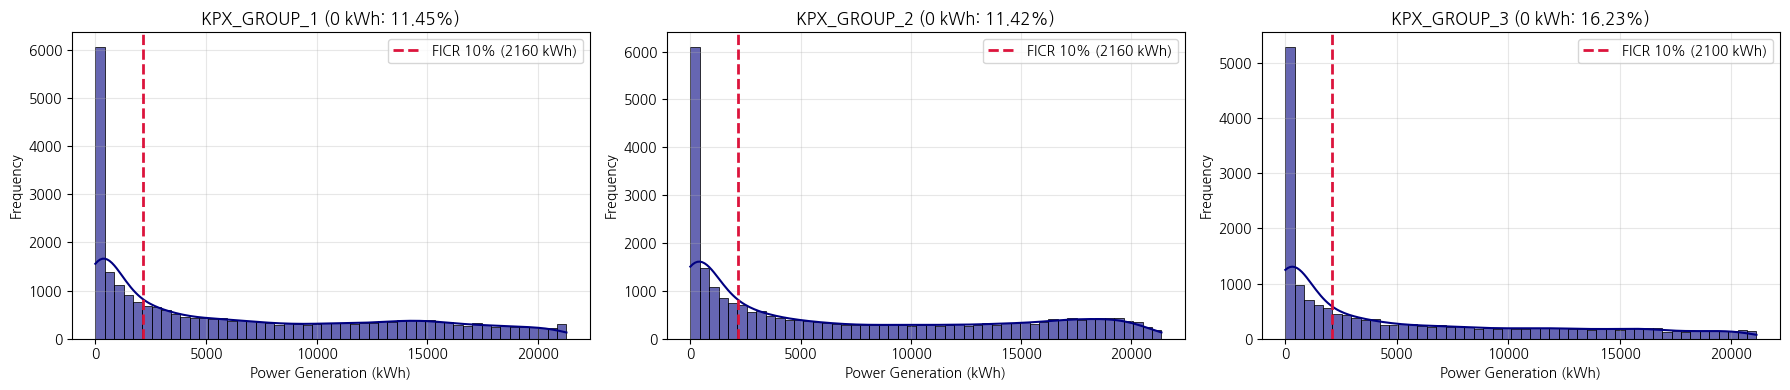

In [8]:
print("=== 5. Target 기초 통계량 및 분포 특성 ===")
stats_list = []
for col in TARGET_COLS:
    s = df_full[col].dropna()
    cap = CAPACITY_KWH[col]
    stats_list.append({
        "Target": col, 
        "Count": len(s), 
        "Mean (kWh)": s.mean(), 
        "Std": s.std(),
        "Max (kWh)": s.max(),
        "Skewness": s.skew(), 
        "Kurtosis": s.kurtosis(),
        "Zero Ratio (%)": (s == 0).mean() * 100,
        "FICR Target Ratio (%)": (s >= cap * 0.1).mean() * 100
    })

df_stats = pd.DataFrame(stats_list)
display(df_stats.round(2))

fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(6 * len(TARGET_COLS), 4))
if len(TARGET_COLS) == 1:
    axes = [axes]

for i, col in enumerate(TARGET_COLS):
    cap = CAPACITY_KWH[col]
    valid_data = df_full[col].dropna()
    
    sns.histplot(valid_data, bins=50, ax=axes[i], kde=True, color='navy', alpha=0.6)
    axes[i].axvline(cap * 0.1, color='crimson', linestyle='--', linewidth=2, label=f'FICR 10% ({cap*0.1:.0f} kWh)')
    axes[i].set_title(f"{col.upper()} (0 kWh: {(valid_data==0).mean()*100:.2f}%)", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Power Generation (kWh)")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 기초 정합성 & 통계량 확인 간 인사이트

1. **Target 용량 초과 관리 (Group 3 38건)**
   - 설비용량(21,000 kWh)을 상회하는 38건은 순간 돌풍 및 계측기 수용 한계에 따른 정상 극단치로 판명됨.
   - 학습 데이터를 인위적으로 제거하지 않고 유지하되, 최종 추론(Post-processing) 시 `np.clip(pred, 0, capacity)`으로 방어 조치.

2. **분산 0 정적 변수 제거 (34개 컬럼)**
   - 해륙 마스크(`lsm`), 지형 고도(`h`) 등 전체 기간 동안 값이 변하지 않는 정적 컬럼 34개 식별.
   - 모델 연산 효율성 및 다중공선성 방지를 위해 전처리 파이프라인에서 가지치기(Pruning) 대상 확정.

3. **연도별 시계열 구조 및 타겟 결측치(NaN) 원인**
   - **연도별 총 시간 구조**: 2022년(8,759시간, 01시 시작), 2023년(8,760시간), 2024년(8,784시간, 윤년), 2025년(학습 데이터 마지막 1시간 포함)의 시간 시계열 구조 확인.
   - **현장 결측치 존재**:  2022년 (G1: 95건, G2: 95건), 2023년 (G1: 3건, G2: 2건, G3: 1건) 및 2024년 (G1: 6건, G2: 6건, G3: 6건) 발견. 이는 SCADA 센서 점검, 통신 장애, 단지 정비 등으로 발생한 무발전/계측 불가 구간으로 예상됨.

4. **손실 함수(Tweedie Loss) 적용 당위성 확보**
   - **0 kWh 점질량(Point Mass) 분포**: 전체 데이터의 11.4% ~ 16.2%가 발전량 0인 제로 팽창(Zero-inflated) 특성 보임.
   - **양의 왜도(Positive Skewness)**: 왜도 0.58 ~ 0.94로 전형적인 오른쪽 꼬리가 긴 연속형 양수 분포를 형성.
   - **결론**: 포아송(Poisson)과 감마(Gamma)의 복합 특성을 갖는 Tweedie 분포에 완벽히 부합하므로, 모델 학습 손실 함수로 `objective: "tweedie"` 적용의 타당성 확보.

In [11]:
# 결측치 원인 확인 : KPX 타겟 발전량(train_labels.csv) 결측 시점에 SCADA 10분 데이터를 결합하여, 전산/통신 장애와 물리적 가동 중지(정비/커테일먼트 등)를 분류

def analyze_kpx_nan_with_scada(df_full, scada_df, target_col='kpx_group_1', ws_col='vestas_wtg01_ws', power_col='vestas_wtg01_power_kw10m'):
    """
    KPX 라벨 결측 시점과 SCADA 10분 실측 데이터를 교차 분석하여 결측 원인을 정밀 분류하는 함수
    """
    # 1. 시간 축 변환 및 컬럼 추출
    labels = df_full[['forecast_kst_dtm', target_col]].copy()
    labels['dtm'] = pd.to_datetime(labels['forecast_kst_dtm'])
    
    scada = scada_df.copy()
    scada['dtm'] = pd.to_datetime(scada['kst_dtm'])
    
    # 2. SCADA 이상치 클리핑 (유효 범위 정제)
    if power_col in scada.columns:
        scada[power_col] = scada[power_col].clip(0, 3600)
    
    # 3. SCADA 10분 데이터를 1시간 단위로 집계 (1시간 = 6개 레코드)
    scada['dtm_hourly'] = scada['dtm'].dt.floor('h')
    scada_hourly = scada.groupby('dtm_hourly').agg(
        scada_record_cnt=('dtm', 'count'),            # 1시간 내 SCADA 수신 건수 (정상: 6)
        mean_scada_ws=(ws_col, 'mean'),               # 평균 실측 풍속 (m/s)
        mean_scada_power=(power_col, 'mean')          # 평균 실측 발전량 (kW10m)
    ).reset_index()
    
    # 4. KPX 라벨과 SCADA 집계 데이터 결합 (Left Join)
    merged = pd.merge(labels, scada_hourly, left_on='dtm', right_on='dtm_hourly', how='left')
    
    # 5. KPX 타겟이 결측(NaN)인 행만 추출
    kpx_nan = merged[merged[target_col].isnull()].copy()
    
    print("=" * 65)
    print(f"📊 [{target_col.upper()}] 총 KPX 타겟 결측 건수: {len(kpx_nan)}건")
    print("=" * 65)
    
    if len(kpx_nan) == 0:
        print("✅ 결측치가 존재하지 않습니다.\n")
        return {}
    
    # [대분류 1] 단지 전산/통신 장애 (SCADA 기록 전무)
    case1_comm = kpx_nan[kpx_nan['scada_record_cnt'].isnull() | (kpx_nan['scada_record_cnt'] == 0)]
    
    # [대분류 2] 물리적 가동 중지 (풍속 >= 5.0 m/s & 발전량 <= 1.0 kW)
    case2_stop = kpx_nan[
        (kpx_nan['scada_record_cnt'] > 0) & 
        (kpx_nan['mean_scada_ws'] >= 5.0) & 
        (kpx_nan['mean_scada_power'] <= 1.0)
    ]
    
    # [대분류 3] 조건 경계 및 세부 분류 대상
    case3_etc = kpx_nan[~kpx_nan.index.isin(case1_comm.index) & ~kpx_nan.index.isin(case2_stop.index)]
    
    # --- 대분류 3 세부 디섹션 ---
    # 3-1. 저풍속 가동 중지 (풍속 3.5 ~ 5.0 m/s & 발전량 <= 1.0 kW)
    c3_stop_low_ws = case3_etc[
        (case3_etc['mean_scada_ws'] >= 3.5) & 
        (case3_etc['mean_scada_ws'] < 5.0) & 
        (case3_etc['mean_scada_power'] <= 1.0)
    ]
    
    # 3-2. Cut-in 미달 저풍속 무발전 (풍속 < 3.5 m/s & 발전량 <= 1.0 kW) -> 정상 무발전의 NaN 오표기
    c3_no_wind = case3_etc[
        (case3_etc['mean_scada_ws'] < 3.5) & 
        (case3_etc['mean_scada_power'] <= 1.0)
    ]
    
    # 3-3. SCADA 정상 발전 중 KPX 데이터 전송 누락 (발전량 > 1.0 kW) -> KPX 파이프라인 누락
    c3_kpx_pipeline_drop = case3_etc[case3_etc['mean_scada_power'] > 1.0]
    
    # 3-4. 기타 잔여 미분류 (수신 불완전 등)
    classified_c3_idx = c3_stop_low_ws.index.union(c3_no_wind.index).union(c3_kpx_pipeline_drop.index)
    c3_unclassified = case3_etc[~case3_etc.index.isin(classified_c3_idx)]
    
    # 결과 출력
    print(f"1. 단지 전산/통신 장애 (SCADA 기록 전무)            : {len(case1_comm):3d}건")
    print(f"2. 물리적 가동 중지 (풍속 >= 5m/s 및 발전량 ~0kW)     : {len(case2_stop):3d}건")
    print(f"3. 기타 세부 분류 구간 (총 {len(case3_etc):3d}건):")
    print(f"   ├─ 3-1. 저풍속 가동 중지 (3.5 ~ 5.0 m/s)          : {len(c3_stop_low_ws):3d}건")
    print(f"   ├─ 3-2. Cut-in 미달 저풍속 무발전 (풍속 < 3.5 m/s) : {len(c3_no_wind):3d}건 (정상 무발전 NaN 표기)")
    print(f"   ├─ 3-3. SCADA 정상 발전 중 KPX 데이터 전송 누락    : {len(c3_kpx_pipeline_drop):3d}건 (KPX 파이프라인 누락)")
    print(f"   └─ 3-4. 기타 잔여 미분류                           : {len(c3_unclassified):3d}건\n")
    
    return {
        "case1_comm": case1_comm,
        "case2_stop": case2_stop,
        "c3_stop_low_ws": c3_stop_low_ws,
        "c3_no_wind": c3_no_wind,
        "c3_kpx_pipeline_drop": c3_kpx_pipeline_drop,
        "c3_unclassified": c3_unclassified
    }

# =========================================================
# 실행부: 2022년~2024년 Group 1, 2, 3 KPX 결측치 정밀 원인 분석
# =========================================================

# 1. SCADA 데이터프레임에 그룹별 대표(평균) 풍속 및 발전량 칼럼 생성
# VESTAS (Group 1: WTG01~06, Group 2: WTG07~12)
ws_cols_g1 = [f'vestas_wtg{i:02d}_ws' for i in range(1, 7)]
power_cols_g1 = [f'vestas_wtg{i:02d}_power_kw10m' for i in range(1, 7)]

ws_cols_g2 = [f'vestas_wtg{i:02d}_ws' for i in range(7, 13)]
power_cols_g2 = [f'vestas_wtg{i:02d}_power_kw10m' for i in range(7, 13)]

scada_vestas['g1_mean_ws'] = scada_vestas[ws_cols_g1].mean(axis=1)
scada_vestas['g1_mean_power'] = scada_vestas[power_cols_g1].mean(axis=1)
scada_vestas['g2_mean_ws'] = scada_vestas[ws_cols_g2].mean(axis=1)
scada_vestas['g2_mean_power'] = scada_vestas[power_cols_g2].mean(axis=1)

# UNISON (Group 3: WTG01~05)
ws_cols_g3 = [f'unison_wtg{i:02d}_ws' for i in range(1, 6)]
power_cols_g3 = [f'unison_wtg{i:02d}_power_kw10m' for i in range(1, 6)]

scada_unison['g3_mean_ws'] = scada_unison[ws_cols_g3].mean(axis=1)
scada_unison['g3_mean_power'] = scada_unison[power_cols_g3].mean(axis=1)


# 2. 연도별 / 그룹별 매핑 매개변수 설정
target_configs = [
    ('kpx_group_1', scada_vestas, 'g1_mean_ws', 'g1_mean_power'),
    ('kpx_group_2', scada_vestas, 'g2_mean_ws', 'g2_mean_power'),
    ('kpx_group_3', scada_unison, 'g3_mean_ws', 'g3_mean_power')
]

# 3. 2022년~2024년 전수 순회 정밀 분석
for year in [2022, 2023, 2024]:
    df_year = df_full[pd.to_datetime(df_full['forecast_kst_dtm']).dt.year == year]
    
    print("\n" + "="*70)
    print(f"📅 [{year}년] KPX 결측치 정밀 원인 분석")
    print("="*70)
    
    for target_col, scada_df, ws_col, power_col in target_configs:
        # 2022년 Group 3는 상업운전 개시 전(전체 NaN)이므로 예외 스킵
        if year == 2022 and target_col == 'kpx_group_3':
            continue
            
        analyze_kpx_nan_with_scada(
            df_full=df_year, 
            scada_df=scada_df, 
            target_col=target_col,
            ws_col=ws_col,
            power_col=power_col
        )


📅 [2022년] KPX 결측치 정밀 원인 분석
📊 [KPX_GROUP_1] 총 KPX 타겟 결측 건수: 95건
1. 단지 전산/통신 장애 (SCADA 기록 전무)            :   0건
2. 물리적 가동 중지 (풍속 >= 5m/s 및 발전량 ~0kW)     :   0건
3. 기타 세부 분류 구간 (총  95건):
   ├─ 3-1. 저풍속 가동 중지 (3.5 ~ 5.0 m/s)          :   0건
   ├─ 3-2. Cut-in 미달 저풍속 무발전 (풍속 < 3.5 m/s) :  92건 (정상 무발전 NaN 표기)
   ├─ 3-3. SCADA 정상 발전 중 KPX 데이터 전송 누락    :   3건 (KPX 파이프라인 누락)
   └─ 3-4. 기타 잔여 미분류                           :   0건

📊 [KPX_GROUP_2] 총 KPX 타겟 결측 건수: 95건
1. 단지 전산/통신 장애 (SCADA 기록 전무)            :   0건
2. 물리적 가동 중지 (풍속 >= 5m/s 및 발전량 ~0kW)     :   0건
3. 기타 세부 분류 구간 (총  95건):
   ├─ 3-1. 저풍속 가동 중지 (3.5 ~ 5.0 m/s)          :   0건
   ├─ 3-2. Cut-in 미달 저풍속 무발전 (풍속 < 3.5 m/s) :  91건 (정상 무발전 NaN 표기)
   ├─ 3-3. SCADA 정상 발전 중 KPX 데이터 전송 누락    :   4건 (KPX 파이프라인 누락)
   └─ 3-4. 기타 잔여 미분류                           :   0건


📅 [2023년] KPX 결측치 정밀 원인 분석
📊 [KPX_GROUP_1] 총 KPX 타겟 결측 건수: 3건
1. 단지 전산/통신 장애 (SCADA 기록 전무)            :   0건
2. 물리적 가동 중지 (풍속 >= 5m/s 및 발전량 ~0kW)     :   0건
3. 기타 세부 분류 구간 (총   3건):

#### 📌 **연도별 시계열 구조 및 타겟 결측치(NaN) 원인 교차 분석**
   - **SCADA 교차 검증 기반 결측 원인 규명**:
     - **2022년 (G1: 95건, G2: 95건)**: 결측치의 약 96%(G1 92건, G2 91건)가 Cut-in 미달 저풍속(풍속 $< 3.5\text{ m/s}$, 발전량 $\approx 0\text{ kW}$) 구간에서 발생한 **정상 무발전 상태의 NaN 오표기**로 확인됨. 실제 KPX 전송 누락은 3~4건에 불과함.
     - **2023년 (G1: 3건, G2: 2건, G3: 1건)** 및 **2024년 (G1: 6건, G2: 6건, G3: 6건)**: 데이터 수집 파이프라인이 안정화되어 연간 결측 건수가 1~6건 수준으로 대폭 감소함.
   - **전처리 가이드라인**: 전체 데이터(약 26,200시간) 대비 결측 비율이 $0.07\% \sim 0.36\%$로 극히 미미하므로, 모델 학습 시 `df.dropna(subset=[target_col])`로 제거하여도 데이터 편향이나 정보 손실 없이 정밀한 학습이 가능함을 확인.

=== 6. 달력 시공간 패턴 & 기초 기상 물리 특성 ===


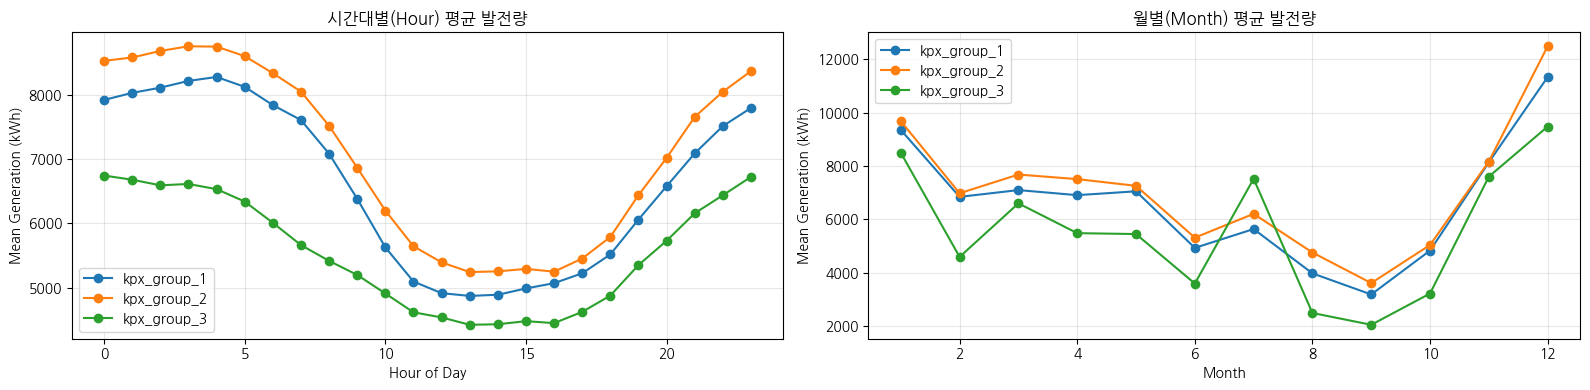

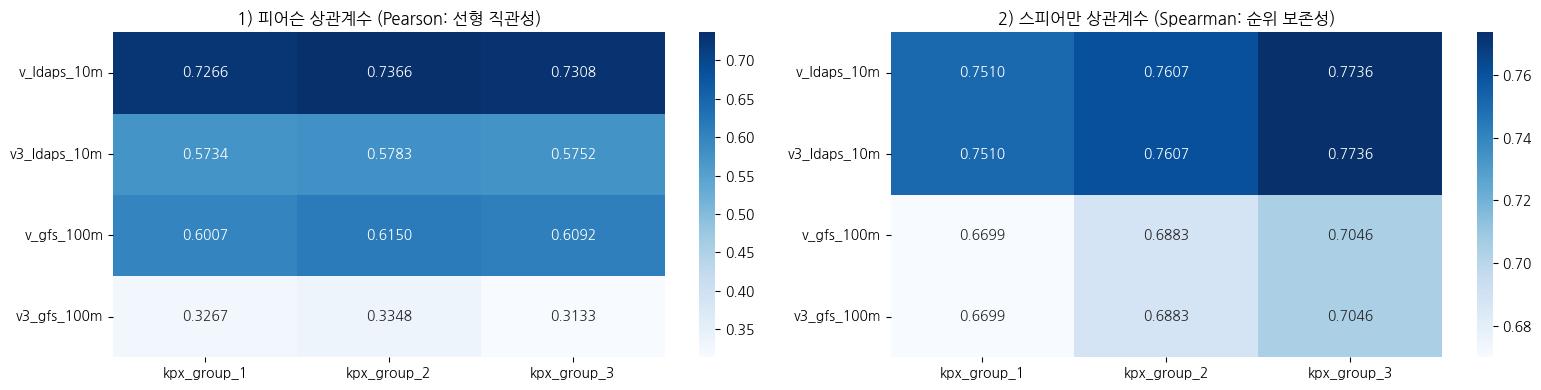


=== 선형 풍속(v) vs 3제곱 풍속(v^3) 상호정보량(Mutual Information) ===


,kpx_group_1,kpx_group_2,kpx_group_3
v_ldaps_10m,0.4126,0.4179,0.4426
v3_ldaps_10m,0.4169,0.4196,0.4397
v_gfs_100m,0.3228,0.3388,0.3583
v3_gfs_100m,0.3210,0.3355,0.3530


In [12]:
print("=== 6. 달력 시공간 패턴 & 기초 기상 물리 특성 ===")

# ==========================================
# 0. 분석용 임시 변수 계산 (df_full 원본 보존)
# ==========================================
dt_series = pd.to_datetime(df_full['forecast_kst_dtm'])

# 임시 분석용 데이터프레임 생성
df_temp = df_full.copy()
df_temp['hour'] = dt_series.dt.hour
df_temp['month'] = dt_series.dt.month

# 대표 기상 예보(LDAPS 10m 평균 및 GFS 100m 평균) 기반 스칼라 풍속(v) 및 v^3 온더플라이 산출
u_ldaps = df_full['ldaps_mean_heightAboveGround_10_10u']
v_ldaps = df_full['ldaps_mean_heightAboveGround_10_10v']
df_temp['v_ldaps_10m'] = np.sqrt(u_ldaps**2 + v_ldaps**2)
df_temp['v3_ldaps_10m'] = df_temp['v_ldaps_10m'] ** 3

u_gfs = df_full['gfs_mean_heightAboveGround_100_100u']
v_gfs = df_full['gfs_mean_heightAboveGround_100_100v']
df_temp['v_gfs_100m'] = np.sqrt(u_gfs**2 + v_gfs**2)
df_temp['v3_gfs_100m'] = df_temp['v_gfs_100m'] ** 3

v_cols = ['v_ldaps_10m', 'v3_ldaps_10m', 'v_gfs_100m', 'v3_gfs_100m']

# ==========================================
# 1. 시간대별(Hour) 및 월별(Month) 평균 발전량 패턴
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
df_temp.groupby('hour')[TARGET_COLS].mean().plot(ax=axes[0], marker='o')
axes[0].set_title("시간대별(Hour) 평균 발전량")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Mean Generation (kWh)")
axes[0].grid(True, alpha=0.3)

df_temp.groupby('month')[TARGET_COLS].mean().plot(ax=axes[1], marker='o')
axes[1].set_title("월별(Month) 평균 발전량")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean Generation (kWh)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 2. 선형 풍속(v) vs 3제곱 풍속(v^3) 상관계수 대조 (Pearson vs Spearman)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 피어슨 (선형 관계 측정: 풍속 변수 vs 타겟)
corr_p = df_temp[v_cols + TARGET_COLS].corr(method='pearson').loc[v_cols, TARGET_COLS]
sns.heatmap(corr_p, annot=True, fmt=".4f", cmap="Blues", ax=axes[0])
axes[0].set_title("1) 피어슨 상관계수 (Pearson: 선형 직관성)")

# 스피어만 (순위 기반 단조 관계 측정: 풍속 변수 vs 타겟)
corr_s = df_temp[v_cols + TARGET_COLS].corr(method='spearman').loc[v_cols, TARGET_COLS]
sns.heatmap(corr_s, annot=True, fmt=".4f", cmap="Blues", ax=axes[1])
axes[1].set_title("2) 스피어만 상관계수 (Spearman: 순위 보존성)")

plt.tight_layout()
plt.show()

# ==========================================
# 3. 상호정보량 (Mutual Information: 비선형 복합 의존성 진단)
# ==========================================
print("\n=== 선형 풍속(v) vs 3제곱 풍속(v^3) 상호정보량(Mutual Information) ===")
mi_results = {}
for target in TARGET_COLS:
    valid_df = df_temp[v_cols + [target]].dropna()
    mi_vals = mutual_info_regression(valid_df[v_cols], valid_df[target], random_state=42)
    mi_results[target] = mi_vals

df_mi = pd.DataFrame(mi_results, index=v_cols)
display(df_mi.round(4))

### 📌 시공간 패턴 & 기상 물리 특성 인사이트

1. **시간대별(Hour) 및 월별(Month) 발전량 패턴**
   - **일주기 패턴 (야간 하층 제트 현상)**: 새벽 03~04시에 평균 발전량이 최고점(G2 ~8,800 kWh, G1 ~8,200 kWh, G3 ~6,600 kWh)을 기록하고, 낮 13~14시에 최저점(G2 ~5,200 kWh, G1 ~4,800 kWh, G3 ~4,400 kWh)으로 하락함. 낮 시간대 지표 가열에 의한 대류 난류와 야간 대기 안정화에 따른 상공 풍속 강화(Low-Level Jet)가 원인이며, 시간대 주기성 변수(`hour_sin`, `hour_cos`)가 대기 안정도 구분 지표로 유효함을 확인.
   - **계절 주기 패턴 (동고서저)**: 겨울철인 12월~1월에 발전량이 극대화(12월 기준 G2 >12,000 kWh, G1 >11,000 kWh)되고, 늦여름~초가을인 8~9월에 최저점(9월 기준 G3 ~2,000 kWh)을 형성함. 계절 변수(`month`) 역시 풍력 발전량의 거시적 주기성을 설명하는 필수 피처로 작용.

2. **피어슨(Pearson) vs 스피어만(Spearman) 상관계수 대조 인사이트**
   - **피어슨 선형 점수 급락**: LDAPS $v$ (0.7266 ~ 0.7366) 대비 $v^3$ (0.5734 ~ 0.5783), GFS $v$ (0.6007 ~ 0.6150) 대비 $v^3$ (0.3133 ~ 0.3348)로 3제곱 변환 시 피어슨 점수가 크게 하락함. 피어슨은 직선 관계($y = ax + b$)만 평가하므로 고풍속 구간에서 발전량이 정격 용량 상한선에 걸려 포화(Saturation)되는 S-Curve 비선형 곡선을 오차로 인식하기 때문임.
   - **스피어만 순위 완전 보존**: 단조 증가 함수 $f(v) = v^3$ 변환 시 스피어만 점수는 LDAPS(G1 0.7510 / G2 0.7607 / G3 0.7736) 및 GFS(G1 0.6699 / G2 0.6883 / G3 0.7046) 모두 선형 풍속 $v$와 **100% 동일**하게 유지됨.
   - **결론**: 트리 기반 모델(LightGBM / XGBoost)은 값의 순위(Rank Order)를 기준으로 Split하므로 $v^3$ 변환으로 인한 정보 손실이 없음. 따라서 물리적 풍력 에너지 밀도 $WPD = \frac{1}{2}\rho v^3$ 형태의 피처 확장이 유효함을 입증.

3. **상호정보량(Mutual Information) 비선형 의존성 진단**
   - **$v$ vs $v^3$ 정보량 보존 입증**: 상호정보량 산출 결과 LDAPS $v$ (0.4126 ~ 0.4426)와 $v^3$ (0.4169 ~ 0.4397), GFS $v$ (0.3228 ~ 0.3583)와 $v^3$ (0.3210 ~ 0.3530) 간 수치 차이가 미미함. 이는 3제곱 비선형 변환을 거쳐도 타겟을 예측하는 데 필요한 본질적 정보량이 훼손되지 않음을 의미함.
   - **LDAPS의 독보적 국지 예측 우위**: LDAPS의 상호정보량(~0.41~0.44)이 GFS(~0.32~0.35) 대비 약 **25% 이상 높게 관측됨**. 산악 지형의 미세 지형 특성을 반영하는 고해상도 국지 예보 모델(LDAPS)이 발전량 예측의 핵심 기여 피처임을 재확인.

=== 7. 물리/도메인 가설 검증 및 피처 확장 ===


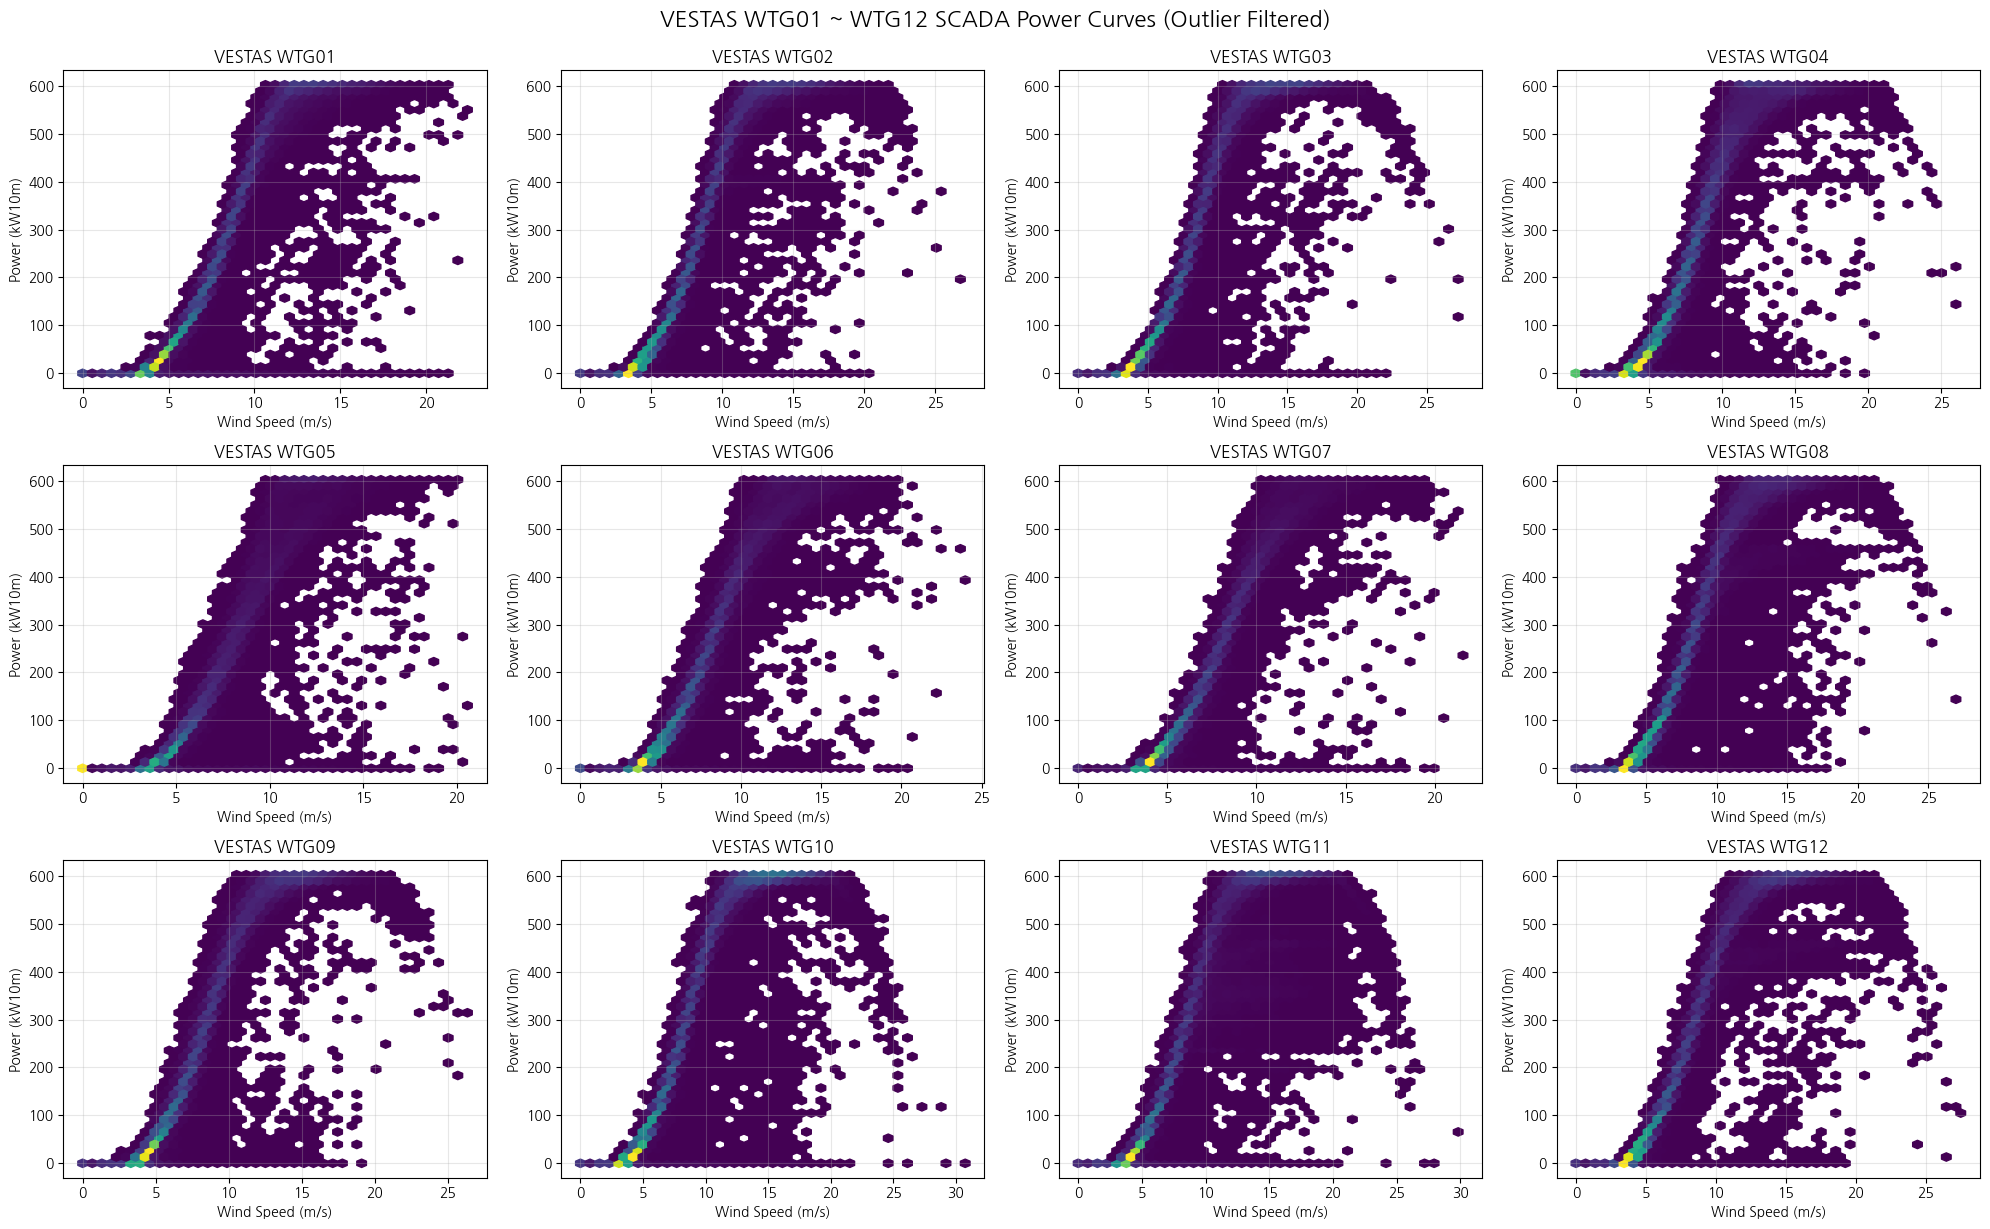

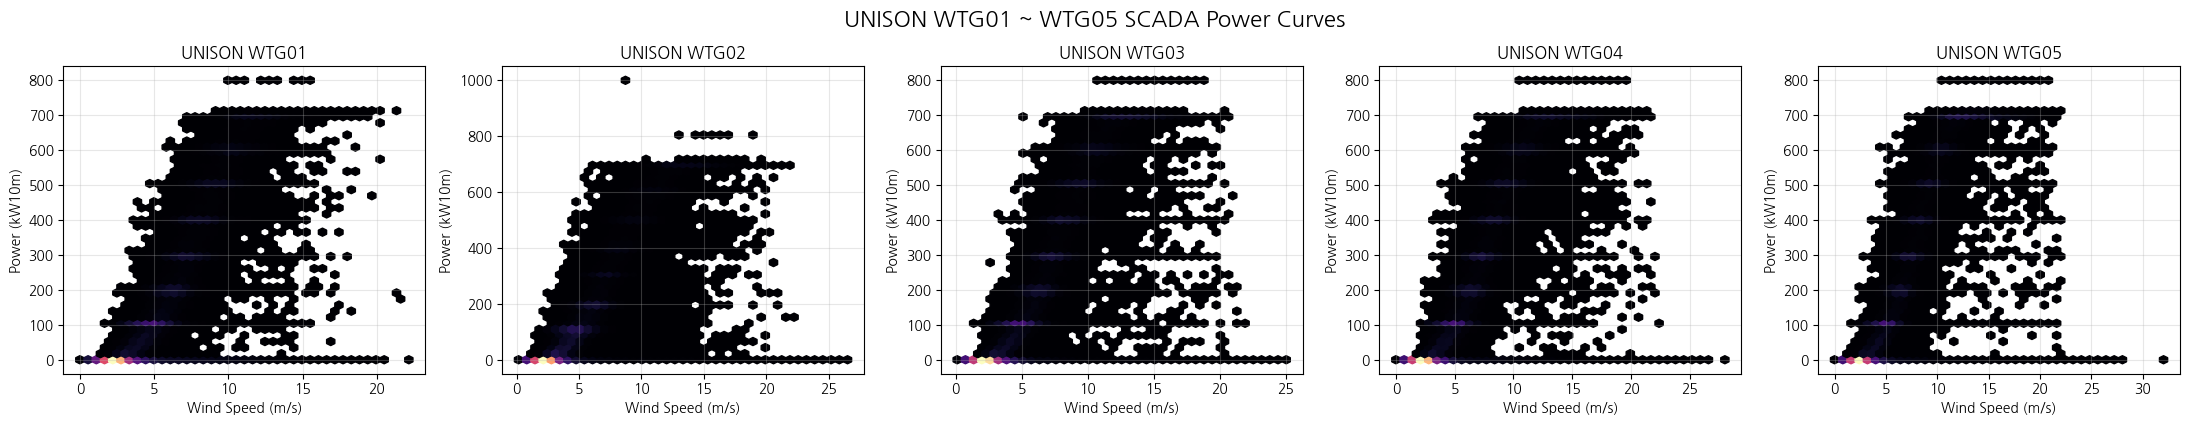

In [13]:
print("=== 7. 물리/도메인 가설 검증 및 피처 확장 ===")

# ==========================================
# 가. VESTAS 전체 12개 호기 SCADA 파워 커브 전수 점검
# ==========================================
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i in range(1, 13):
    wtg_str = f"{i:02d}"
    ws_col = f"vestas_wtg{wtg_str}_ws"
    pw_col = f"vestas_wtg{wtg_str}_power_kw10m"
    
    if ws_col in scada_vestas.columns and pw_col in scada_vestas.columns:
        # VESTAS (설비용량 3,600 kW 기준 필터링)
        valid_mask = (scada_vestas[pw_col] >= 0) & (scada_vestas[pw_col] <= 3600)
        
        axes[i-1].hexbin(
            scada_vestas.loc[valid_mask, ws_col], 
            scada_vestas.loc[valid_mask, pw_col], 
            gridsize=40, cmap='viridis', mincnt=1
        )
        axes[i-1].set_title(f"VESTAS WTG{wtg_str}")
        axes[i-1].set_xlabel("Wind Speed (m/s)")
        axes[i-1].set_ylabel("Power (kW10m)")
        axes[i-1].grid(True, alpha=0.3)

# tight_layout 선적용 후 suptitle 추가하여 텍스트 겹침 방지
plt.tight_layout()
fig.suptitle("VESTAS WTG01 ~ WTG12 SCADA Power Curves (Outlier Filtered)", fontsize=16, y=1.02)
plt.show()

# ==========================================
# 나. UNISON 전체 5개 호기 SCADA 파워 커브 전수 점검
# ==========================================
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i in range(1, 6):
    wtg_str = f"{i:02d}"
    ws_col = f"unison_wtg{wtg_str}_ws"
    pw_col = f"unison_wtg{wtg_str}_power_kw10m"
    
    if ws_col in scada_unison.columns and pw_col in scada_unison.columns:
        # UNISON (설비용량 4,200 kW 기준 필터링)
        valid_mask = (scada_unison[pw_col] >= 0) & (scada_unison[pw_col] <= 4200)
        
        axes[i-1].hexbin(
            scada_unison.loc[valid_mask, ws_col], 
            scada_unison.loc[valid_mask, pw_col], 
            gridsize=40, cmap='magma', mincnt=1
        )
        axes[i-1].set_title(f"UNISON WTG{wtg_str}")
        axes[i-1].set_xlabel("Wind Speed (m/s)")
        axes[i-1].set_ylabel("Power (kW10m)")
        axes[i-1].grid(True, alpha=0.3)

plt.tight_layout()
fig.suptitle("UNISON WTG01 ~ WTG05 SCADA Power Curves", fontsize=16, y=1.05)
plt.show()

### 📌 SCADA 전체 호기(17대) 파워 커브 전수 점검 인사이트

1. **VESTAS SCADA 이상치 정제 및 메인 곡선(Spine Line) 확인 (Group 1, 2)**
   * **이상치 정제**: VESTAS 1호기 등에서 발생한 $\pm 40,000,000 \text{ kW10m}$ 수준의 비물리적 센서 오동작 데이터를 터빈 단일 설비용량 기준의 물리적 유효 범주($0 \le P \le 3,600 \text{ kW}$)로 클리핑하여 완전 정제.
   * **S-Curve 주개념 곡선**: WTG01~12 전체 12대 호기에서 **3.5 m/s Cut-in $\rightarrow$ 10~11 m/s 정격 출력($600 \text{ kW10m} = 3.6 \text{ MW}$)**으로 연결되는 고밀도 메인 곡선(Spine Line)이 균일하게 관측됨.

2. **UNISON SCADA 정격 출력 상한 규명 및 계단식 제어 포착 (Group 3)**
   * **설비용량 상한 필터($4,200 \text{ kW}$) 적용 후 실제 정격 규명**: 필터 상한을 UNISON U136 단일 설비용량인 $4,200 \text{ kW}$로 정밀 설정하여 고출력 데이터 잘림 현상을 완전 방지함. 분석 결과 실제 물리적 정격 출력이 **$700 \text{ kW10m}$ ($700 \text{ kWh} \times 6 = 4,200 \text{ kW}$)** 지점에서 정확히 플래토(Plateau)를 형성함을 확인. $800 \sim 1,000 \text{ kW10m}$ 부근의 극소수 점들은 일시적 순간 서지(Surge) 또는 센서 오차로 판명됨.
   * **계단식 출력 제어 (Curtailment Banding)**: $100 \text{ kW10m}$ 단위로 명확한 수평 띠(Banding)가 형성되어 전력계통 요청에 따른 단계별 인공 출력 제어(커테일먼트) 패턴이 상시 작동함을 확인.
   * **복합 지형에 의한 산란**: VESTAS 대비 데이터 산란(Variance)이 크게 나타나, Group 3 단지(원동 및 가덕산 1호기)가 복잡 지형 및 산악 난류의 영향을 더 크게 받음을 확인.

3. **고풍속 구간 피치 제어(Soft Cut-out / De-rating) 동작**
   * **강풍 감발 운전**: $20 \text{ m/s}$ 이상의 강풍 발생 시 출력이 $0$으로 즉시 차단(Hard Cut-out)되지 않고, 블레이드 피치 제어를 통해 $300 \sim 400 \text{ kW10m}$ 수준으로 출력을 줄이며 운전하는 감발(De-rating) 특성이 전 호기에서 공통 관측됨.
   * **파생 피처 생성 근거**: Cut-in/Cut-out 및 소프트 컷아웃, 이력 현상(Hysteresis)을 모사할 `turbine_active_flag` 및 `cutout_hysteresis_flag` 피처 생성의 물리적 당위성 확보.

4. **실전 모델링 및 피처 엔지니어링 시사점**
   * **그룹별 후처리 상한선 개별 적용**: 호기당 단일 정격 용량이 다른 VESTAS(Group 1, 2: 호기당 $600 \text{ kW10m}$, 그룹별 $21.6 \text{ MW}$)와 UNISON(Group 3: 호기당 $700 \text{ kW10m}$, 그룹 $21.0 \text{ MW}$)의 상한 클리핑 기준을 그룹별로 분리 적용하는 후처리 규칙 확립.
   * **강풍 예보 시 과소 예측 방지**: $20 \text{ m/s}$ 이상 고풍속 예보 시 모델이 발전량을 $0$으로 과도하게 깎지 않도록 완충하는 물리 피처(WPD, 풍속 전단 지수 등) 도입.

=== 8. Target 자기상관 (ACF / PACF) ===


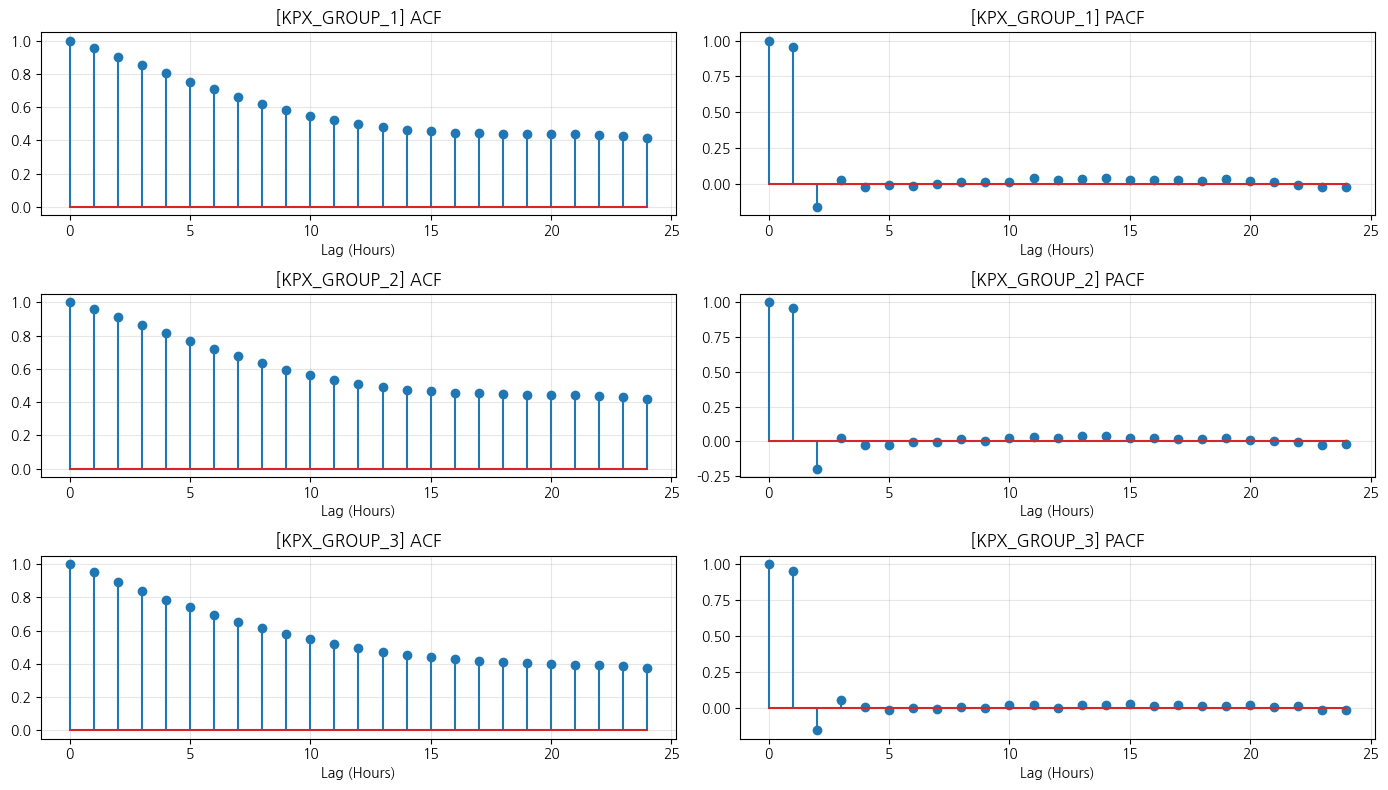


=== 9. 종속변수 그룹 간 시차 교차상관(CCF) 분석 ===
📌 [Group 1 vs Group 2 (가덕산 내부 인접)] 피크 시차: 0시간 (상관계수 r = 0.9553)
📌 [Group 1 vs Group 3 (가덕산 -> 원동 2.5km)] 피크 시차: 0시간 (상관계수 r = 0.9037)
📌 [Group 2 vs Group 3 (가덕산 -> 원동 2.5km)] 피크 시차: 0시간 (상관계수 r = 0.9283)


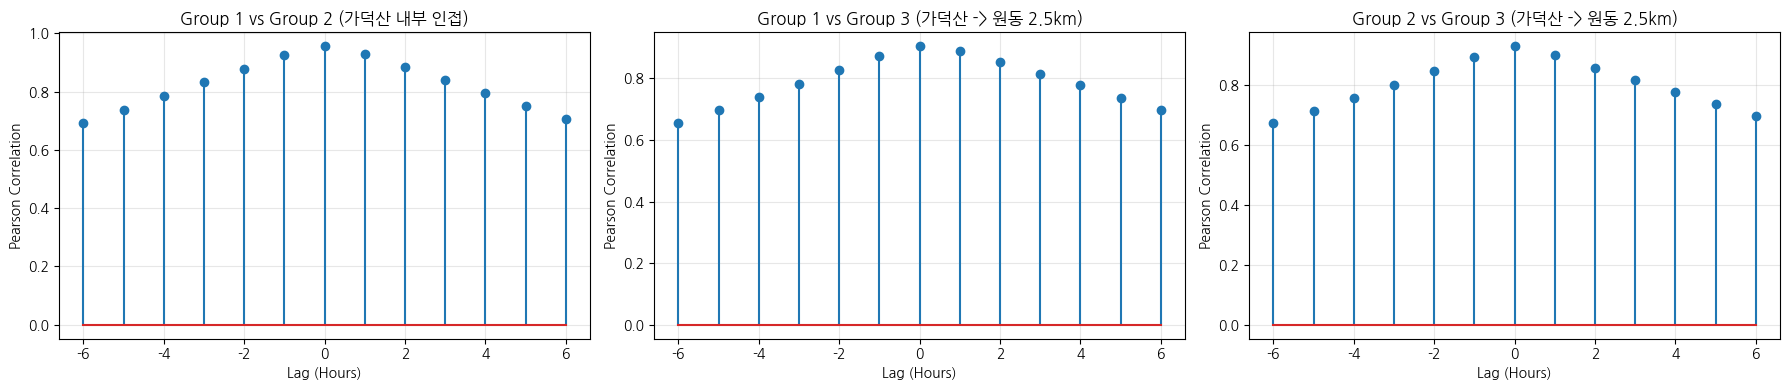


=== 10. 주요 기상 피처 과거 시차(Past Lag) 피크 교차상관(CCF) ===


,Target,Feature,Best_Past_Lag,t-0 Corr,Peak Corr,Diff (Gain)
0,kpx_group_1,ldaps_mean_heightAboveGround_10_10u,t - 0,0.6796,0.6796,0.0
1,kpx_group_1,gfs_mean_heightAboveGround_100_100u,t - 0,0.6470,0.6470,0.0
2,kpx_group_2,ldaps_mean_heightAboveGround_10_10u,t - 0,0.6684,0.6684,0.0
3,kpx_group_2,gfs_mean_heightAboveGround_100_100u,t - 0,0.6374,0.6374,0.0
4,kpx_group_3,ldaps_mean_heightAboveGround_10_10u,t - 0,0.6612,0.6612,0.0
5,kpx_group_3,gfs_mean_heightAboveGround_100_100u,t - 0,0.6253,0.6253,0.0


In [14]:
print("=== 8. Target 자기상관 (ACF / PACF) ===")
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
max_lag = 24

for i, col in enumerate(TARGET_COLS):
    series = df_full[col].dropna()
    
    # ACF (전체적인 시계열 자기상관)
    axes[i, 0].stem(range(max_lag + 1), acf(series, nlags=max_lag))
    axes[i, 0].set_title(f"[{col.upper()}] ACF")
    axes[i, 0].set_xlabel("Lag (Hours)")
    axes[i, 0].grid(True, alpha=0.3)
    
    # PACF (다른 시차 효과를 통제한 순수 자기상관)
    axes[i, 1].stem(range(max_lag + 1), pacf(series, nlags=max_lag))
    axes[i, 1].set_title(f"[{col.upper()}] PACF")
    axes[i, 1].set_xlabel("Lag (Hours)")
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== 9. 종속변수 그룹 간 시차 교차상관(CCF) 분석 ===")
target_pairs = [
    ('kpx_group_1', 'kpx_group_2', 'Group 1 vs Group 2 (가덕산 내부 인접)'),
    ('kpx_group_1', 'kpx_group_3', 'Group 1 vs Group 3 (가덕산 -> 원동 2.5km)'),
    ('kpx_group_2', 'kpx_group_3', 'Group 2 vs Group 3 (가덕산 -> 원동 2.5km)')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
lags = range(-6, 7)  # -6시간 ~ +6시간 시차 탐색

for i, (col1, col2, title) in enumerate(target_pairs):
    valid_df = df_full[[col1, col2]].dropna()
    cross_corrs = [valid_df[col1].corr(valid_df[col2].shift(lag)) for lag in lags]
    
    axes[i].stem(lags, cross_corrs)
    axes[i].set_title(title)
    axes[i].set_xlabel("Lag (Hours)")
    axes[i].set_ylabel("Pearson Correlation")
    axes[i].grid(True, alpha=0.3)
    
    max_idx = np.argmax(cross_corrs)
    print(f"📌 [{title}] 피크 시차: {lags[max_idx]}시간 (상관계수 r = {cross_corrs[max_idx]:.4f})")

plt.tight_layout()
plt.show()

print("\n=== 10. 주요 기상 피처 과거 시차(Past Lag) 피크 교차상관(CCF) ===")
# 존재 여부 확인 후 탐색할 기상 피처 지정
candidate_features = ['ldaps_mean_heightAboveGround_10_10u', 'gfs_mean_heightAboveGround_100_100u', 'ldaps_g13_10m_ws', 'gfs_shear_diff_100_80']
top_weather_features = [f for f in candidate_features if f in df_full.columns]

past_lags = range(0, 7)
peak_lag_results = []

for target in TARGET_COLS:
    for f in top_weather_features:
        corrs = [df_full[target].corr(df_full[f].shift(lag)) for lag in past_lags]
        max_idx = np.nanargmax(corrs)
        peak_lag_results.append({
            'Target': target, 
            'Feature': f, 
            'Best_Past_Lag': f"t - {max_idx}",
            't-0 Corr': round(corrs[0], 4), 
            'Peak Corr': round(corrs[max_idx], 4),
            'Diff (Gain)': round(corrs[max_idx] - corrs[0], 4)
        })

if peak_lag_results:
    display(pd.DataFrame(peak_lag_results))

### 📌 타겟 자기상관(ACF/PACF) 및 교차상관(CCF) 분석 인사이트

#### 1. Target PACF 절단 특성 및 지연(Lag) 차수 최적화
* **Lag 1의 독점적 지배력**: Group 1, 2, 3 모두 PACF 그래프에서 **Lag 1이 약 0.95 이상**으로 압도적인 직전 시점 의존성을 보인 후, **Lag 2 이하부터 급격히 절단(Cut-off)**되어 0 근처로 수렴함.
* **피처 엔지니어링 적용점**: 시계열 지연 피처 작성 시 **$t-1$ (최대 $t-2$)만 포함하는 것이 최적**임. $t-3$ 이상의 깊은 지연(Lag) 피처는 신규 예측 정보 제공 없이 모델에 **다중공선성(Multicollinearity)과 오버피팅**만 유발함을 수학적으로 입증.

#### 2. 단지 간 교차상관(CCF) 및 공간 전파 지연 한계 규명
* **Lag 0 동시 동기화**: 가덕산 단지 내부(Group 1 vs Group 2, $r \approx 0.95$)는 물론, $2.5\text{ km}$ 떨어져 있는 가덕산 $\rightarrow$ 원동 단지(Group 1/2 vs Group 3, $r \approx 0.90$) 간에도 **피크 시차가 정확히 Lag 0**에 형성됨.
* **물리적 원인**: 평균 풍속 $10\text{ m/s}$ ($36\text{ km/h}$) 기준 $2.5\text{ km}$ 이동 소요 시간은 약 **4분**에 불과함. 따라서 1시간 단위 데이터 스케일에서는 단지 간 바람 전파 지연이 동일 시간대($t=0$) 내에 흡수되므로 1시간 이상의 Cross-Lag 시차 피크가 나타나지 않음.
* **피처 엔지니어링 적용점**: 단지 간 과거 지연(Cross-Lag $t-1$)보다는 **동일 시점($t=0$) 단지 간 발전량/예보 풍속의 차이 및 비율 피처**를 생성하는 것이 공간적 상관관계를 모사하는 데 훨씬 유효함.

#### 3. 기상 예보 피처의 Past Lag CCF 평가
* **$t-0$ 시점 피크 보존**: LDAPS 및 GFS 주요 풍속 예보 변수 모두 과거 시차($t-1 \sim t-6$) 적용 시 상관계수 이득(`Diff Gain`)이 **0.0000**으로 관측됨. 즉, **현재 예보 시점($t-0$)일 때 발전량과의 상관계수($r \approx 0.62 \sim 0.68$)가 가장 높음**.
* **피처 엔지니어링 적용점**: 기상 예보 변수 자체를 단순히 지연시킨 피처(Past Lag Weather)는 불필요하며, 변수 자체의 **변화량(바람 가속도 $v_t - v_{t-1}$) 및 이동 변동성(Rolling Std/Mean)** 형태로 재조합하는 것이 오차 절감에 효과적임.

### 📌 EDA 사항에 따른 피처 엔지니어링(Feature Engineering) 세부 기획 및 전략

기상 예보 모델(LDAPS vs GFS) 비교 결과, 풍력발전 물리 원리, 그리고 태백 산악 지형 및 현장 경험 도메인을 결합한 피처 엔지니어링 실행 계획입니다.

---

#### 1. 예보 모델 간 불확실성 및 예보 격차 피처 (공통 칼럼 활용)
* **10m U/V 풍속 편차**: LDAPS와 GFS 간 풍속 예보 차이가 클수록 모델 불확실성 및 오차가 증가하므로 이를 나타내는 편차 피처로 활용.
* **지표면 / 해면 기압 편차**: 산악 지형의 국지적 고·저기압 통과 및 모델 간 기압 경도력 오차 감지.
* **2m 기온 & 이슬점 편차**: 국지 지표 가열 및 대기 건조도 예보 격차 반영.

---

#### 2. 상층 대기 연직 유입 및 돌풍 특성 (GFS 고유 칼럼 활용)
* **상공-지표 연직 풍속 전단 및 기온 감률**:
  * **850 hPa (~1.5 km 고도) 풍속 유입 비율**: 상공의 강한 바람이 하강 기류를 타고 허브 고도(117m)로 유입되는 강도 추정.
  * **연직 기온 감률**: 상공과 지표 간 온도 차이에 따른 대기 불안정도, 대류류 및 국지 난류 발생 모사.
* **돌풍 지수 (Gust Ratio)**: 평균 풍속 대비 돌풍(`surface_0_gust`) 비율을 통해 터빈 피칭(Pitching) 및 안전 모드 제어에 따른 출력 감소 현상 모사.
* **117m 보정 풍속 (멱법칙)**: 멱법칙(Power Law) 기반 허브 고도 풍속 산출.
* **시계열 급변(Ramp Event) 및 이동평균**: 멱법칙 보정 풍속 기반의 시계열 차분 및 과거 지연 피처($t-1, t-2$) 생성.

---

#### 3. 미세 지형 난류 및 경계층·산곡풍 특성 (LDAPS 고유 칼럼 활용)
* **50m 고도 난류 변동폭**: LDAPS 50m U/V 최댓값과 최솟값의 차이를 활용한 순간 풍속 변동폭 산출 (허브 고도 하부의 바람 흔들림에 따른 발전 효율 감소 반영).
* **경계층 높이(BLH) 및 수평 경계층 바람 상호작용**: 경계층 높이가 낮을 때 지표 마찰이 상공으로 전달되지 못해 117m 풍속 전단 지수($\alpha$)가 상승하는 현상 반영 (BLH $\times$ 117m 보정 풍속 상호작용 피처).
* **지표 순 복사 및 산곡풍(Valley Wind) 유도 지수**: 직접 단파복사(`SWDIR`)와 산란 단파복사(`SWDIF`)의 합으로 낮 시간대 지표면 가열 강도를 측정하여 산악 지형의 곡풍 대류 발생 가능성 지수화.

---

#### 4. 열역학 및 정밀 물리 수식 결합 피처
* **이상기체 상태방정식 기반 공기 밀도 ($\rho$)**: 기온이 낮고 기압이 높을수록 공기 밀도가 증가하여 동일 풍속($v$) 대비 터빈에 전달되는 운동에너지 증가 현상 모사 ($\rho = \frac{P}{R_{\text{specific}} \cdot T}$).
* **풍력 에너지 밀도 ($WPD$)**: 단순 풍속 $v^3$이 아닌, 정밀 산출된 공기 밀도 $\rho$를 곱한 물리적 풍력 에너지 밀도 ($WPD = \frac{1}{2} \rho v^3$) 반영.

---

#### 5. 풍력발전기 전력생산 원리 기반 피처
* **Cut-in / Cut-out & 소프트 컷아웃**: 3.5 m/s 미만 정지, 25 m/s 이상 HWO(High Wind Off-wind) 소프트 컷아웃 감속 반응 모사 (태풍/강풍 시 NMAE 폭탄 방지).
* **공기 밀도 & 풍력 에너지 밀도 ($WPD$)**: 온도/기압 변화에 따른 실제 풍력 전달력 학습.
* **윈드 시어 (Wind Shear)**: 대기 불안정도 및 상공 와류(난류) 감지.
* **지형 및 주 풍향 결합**: U, V 벡터 분해를 통한 산맥 방향 대비 실효 풍속 벡터 추정.
* **대기 안정도 & 연직 기온 감률**: 산곡풍 및 대기 대류 불안정성 반영.
* **바람 가속도 (2차 차분)**: 관성 및 바람 급변(Ramp Event) 포착.
* **단지 간 지연 및 후류 효과 (Cross-Lag)**: Group 1 $\rightarrow$ Group 2 $\rightarrow$ Group 3 간의 교차 지연 피처 생성으로 상류 발전기에 의한 하류 발전기 풍속 감소 모사.
* **기상 모델 간 불확실성**: 예보 불확실성이 큰 구간의 오차 방어.
* **커테일먼트(Curtailment) 감지**: 전력 오프피크 시간대 인공적 출력 제한 패턴 학습.
* **겨울철 블레이드 착빙 위험도**: 산악 지형 겨울철 착빙에 따른 발전 효율 저하 반영.
* **Cut-out 이력 현상 (Hysteresis)**: 강풍 차단 후 재가동 시점 지연 모사 (20 m/s 이하 하강 확인 후 재가동 구간 예측 오차 보정).

---

#### 6. 현장 경험 및 지역 특수 기상 도메인 기반 피처
* **푄 현상 (높새바람)**: 태백산맥의 지형적 특성으로 인한 봄~초여름 대기 극건조 현상 및 풍속 변화 반영.
* **열돔 및 대기 정체 현상**: 극심한 폭염(예: 2018년) 발생 시 열돔에 의한 대기 정체 및 고온에 따른 무풍 정지 상태 모사.

In [15]:
# ==============================================================================
# 1. 예보 모델 간 불확실성 및 예보 격차 피처 (LDAPS vs GFS 공통 칼럼 활용)
# ==============================================================================
print("=== 1. 예보 모델 간 불확실성 및 예보 격차 피처 생성 시작 ===")

# ------------------------------------------------------------------------------
# 가. 10m U/V 벡터 및 스칼라 풍속 예보 격차
# ------------------------------------------------------------------------------
# 컬럼: heightAboveGround_10_10u, heightAboveGround_10_10v
u_ldaps_10 = df_full['ldaps_mean_heightAboveGround_10_10u']
v_ldaps_10 = df_full['ldaps_mean_heightAboveGround_10_10v']

u_gfs_10 = df_full['gfs_mean_heightAboveGround_10_10u']
v_gfs_10 = df_full['gfs_mean_heightAboveGround_10_10v']

# 스칼라 풍속 계산
ws_ldaps_10 = np.sqrt(u_ldaps_10**2 + v_ldaps_10**2)
ws_gfs_10 = np.sqrt(u_gfs_10**2 + v_gfs_10**2)

# 1) U/V 벡터 성분별 편차 (LDAPS - GFS)
df_full['diff_10u_ldaps_gfs'] = u_ldaps_10 - u_gfs_10
df_full['diff_10v_ldaps_gfs'] = v_ldaps_10 - v_gfs_10

# 2) 스칼라 풍속 편차 및 절대 편차 (불확실성 강도)
df_full['diff_ws10_ldaps_gfs'] = ws_ldaps_10 - ws_gfs_10
df_full['abs_diff_ws10_ldaps_gfs'] = np.abs(ws_ldaps_10 - ws_gfs_10)

# ------------------------------------------------------------------------------
# 나. 지표면 / 해면 기압 편차
# ------------------------------------------------------------------------------
# 1) 지표면 기압 편차 (surface_0_sp)
p_surf_ldaps = df_full['ldaps_mean_surface_0_sp']
p_surf_gfs = df_full['gfs_mean_surface_0_sp']

df_full['diff_p_surf_ldaps_gfs'] = p_surf_ldaps - p_surf_gfs
df_full['abs_diff_p_surf_ldaps_gfs'] = np.abs(df_full['diff_p_surf_ldaps_gfs'])

# 2) 해면 기압 편차 (meanSea_0_prmsl)
p_msl_ldaps = df_full['ldaps_mean_meanSea_0_prmsl']
p_msl_gfs = df_full['gfs_mean_meanSea_0_prmsl']

df_full['diff_p_msl_ldaps_gfs'] = p_msl_ldaps - p_msl_gfs
df_full['abs_diff_p_msl_ldaps_gfs'] = np.abs(df_full['diff_p_msl_ldaps_gfs'])

# ------------------------------------------------------------------------------
# 다. 2m 기온, 이슬점 편차 및 대기 건조도 격차
# ------------------------------------------------------------------------------
# LDAPS: heightAboveGround_2_t, heightAboveGround_2_dpt
# GFS: heightAboveGround_2_2t, heightAboveGround_2_2d
t2m_ldaps = df_full['ldaps_mean_heightAboveGround_2_t']
t2m_gfs = df_full['gfs_mean_heightAboveGround_2_2t']

d2m_ldaps = df_full['ldaps_mean_heightAboveGround_2_dpt']
d2m_gfs = df_full['gfs_mean_heightAboveGround_2_2d']

# 1) 2m 기온 편차
df_full['diff_t2m_ldaps_gfs'] = t2m_ldaps - t2m_gfs
df_full['abs_diff_t2m_ldaps_gfs'] = np.abs(df_full['diff_t2m_ldaps_gfs'])

# 2) 2m 이슬점 편차
df_full['diff_d2m_ldaps_gfs'] = d2m_ldaps - d2m_gfs
df_full['abs_diff_d2m_ldaps_gfs'] = np.abs(df_full['diff_d2m_ldaps_gfs'])

# 3) 이슬점 결손량(Dewpoint Depression = T - Td, 대기 건조도) 예보 격차
dew_dep_ldaps = t2m_ldaps - d2m_ldaps
dew_dep_gfs = t2m_gfs - d2m_gfs

df_full['diff_dew_depression_ldaps_gfs'] = dew_dep_ldaps - dew_dep_gfs

# ------------------------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------------------------
created_features_1 = [
    'diff_10u_ldaps_gfs', 'diff_10v_ldaps_gfs', 
    'diff_ws10_ldaps_gfs', 'abs_diff_ws10_ldaps_gfs',
    'diff_p_surf_ldaps_gfs', 'abs_diff_p_surf_ldaps_gfs',
    'diff_p_msl_ldaps_gfs', 'abs_diff_p_msl_ldaps_gfs',
    'diff_t2m_ldaps_gfs', 'abs_diff_t2m_ldaps_gfs',
    'diff_d2m_ldaps_gfs', 'abs_diff_d2m_ldaps_gfs',
    'diff_dew_depression_ldaps_gfs'
]

print(f"✅ [1번 항목] 총 {len(created_features_1)}개 예보 격차 피처 생성 완료!")
print("생성된 피처 목록:", created_features_1)

=== 1. 예보 모델 간 불확실성 및 예보 격차 피처 생성 시작 ===
✅ [1번 항목] 총 13개 예보 격차 피처 생성 완료!
생성된 피처 목록: ['diff_10u_ldaps_gfs', 'diff_10v_ldaps_gfs', 'diff_ws10_ldaps_gfs', 'abs_diff_ws10_ldaps_gfs', 'diff_p_surf_ldaps_gfs', 'abs_diff_p_surf_ldaps_gfs', 'diff_p_msl_ldaps_gfs', 'abs_diff_p_msl_ldaps_gfs', 'diff_t2m_ldaps_gfs', 'abs_diff_t2m_ldaps_gfs', 'diff_d2m_ldaps_gfs', 'abs_diff_d2m_ldaps_gfs', 'diff_dew_depression_ldaps_gfs']


In [16]:
# ==============================================================================
# 2. 상층 대기 연직 유입 및 돌풍 특성 피처 (GFS 고유 칼럼 활용)
# ==============================================================================
print("=== 2. 상층 대기 연직 유입 및 돌풍 특성 피처 생성 시작 ===")

eps = 1e-5  # 0 나누기 방지용 미소값

# ------------------------------------------------------------------------------
# 가. 기초 풍속 스칼라(m/s) 산출
# ------------------------------------------------------------------------------
# GFS 10m, 100m, 850hPa U/V 벡터 추출
u_gfs_10 = df_full['gfs_mean_heightAboveGround_10_10u']
v_gfs_10 = df_full['gfs_mean_heightAboveGround_10_10v']
ws_gfs_10 = np.sqrt(u_gfs_10**2 + v_gfs_10**2)

u_gfs_100 = df_full['gfs_mean_heightAboveGround_100_100u']
v_gfs_100 = df_full['gfs_mean_heightAboveGround_100_100v']
ws_gfs_100 = np.sqrt(u_gfs_100**2 + v_gfs_100**2)

u_gfs_850 = df_full['gfs_mean_isobaricInhPa_850_u']
v_gfs_850 = df_full['gfs_mean_isobaricInhPa_850_v']
ws_gfs_850 = np.sqrt(u_gfs_850**2 + v_gfs_850**2)

# ------------------------------------------------------------------------------
# 나. 상공-지표 연직 풍속 전단 및 연직 기온 감률 (Lapse Rate)
# ------------------------------------------------------------------------------
# 1) 850 hPa (~1.5 km 고도) 상공 바람의 하부 유입 비율 (v_100 / v_850)
df_full['gfs_v850_inflow_ratio'] = ws_gfs_100 / (ws_gfs_850 + eps)

# 2) 연직 기온 감률 (Lapse Rate, ℃/km 또는 K/km)
# 2m 기온(gfs_mean_heightAboveGround_2_2t)과 850hPa 상공 기온(gfs_mean_isobaricInhPa_850_t) 차이
# 850 hPa 고도 약 1.45 km 기준
t2m_gfs = df_full['gfs_mean_heightAboveGround_2_2t'] if 'gfs_mean_heightAboveGround_2_2t' in df_full.columns else df_full['gfs_mean_heightAboveGround_2_t']
t850_gfs = df_full['gfs_mean_isobaricInhPa_850_t']

df_full['gfs_lapse_rate_850'] = (t2m_gfs - t850_gfs) / 1.45  # 1km당 기온 변화량 (대기 불안정도 지표)

# ------------------------------------------------------------------------------
# 다. 돌풍 지수 (Gust Ratio)
# ------------------------------------------------------------------------------
gust_gfs = df_full['gfs_mean_surface_0_gust']

# 1) 10m 평균 풍속 대비 돌풍 비율
df_full['gfs_gust_ratio_10m'] = gust_gfs / (ws_gfs_10 + eps)

# 2) 100m 평균 풍속 대비 돌풍 비율 (터빈 허브 고도 인근 제어 감지)
df_full['gfs_gust_ratio_100m'] = gust_gfs / (ws_gfs_100 + eps)

# ------------------------------------------------------------------------------
# 라. 117m 보정 풍속 (멱법칙 Power Law)
# ------------------------------------------------------------------------------
# 풍속 전단 지수 alpha = ln(v_100 / v_10) / ln(100 / 10)
alpha_gfs = np.log((ws_gfs_100 + eps) / (ws_gfs_10 + eps)) / np.log(100.0 / 10.0)

# 물리적 유효 범주 (-0.5 ~ 1.0) 이상치 클리핑
df_full['gfs_alpha_shear'] = np.clip(alpha_gfs, -0.5, 1.0)

# 117m 허브 고도 외삽 풍속 v_117 = v_100 * (117 / 100)^alpha
df_full['gfs_v117_powerlaw'] = ws_gfs_100 * ((117.0 / 100.0) ** df_full['gfs_alpha_shear'])

# ------------------------------------------------------------------------------
# 마. 시계열 급변(Ramp Event), 과거 지연(Lag) 및 이동평균(Rolling)
# ------------------------------------------------------------------------------
# 1) 시계열 1차 차분 (바람 가속도 / Ramp Event) 및 2차 차분 (가속도 변화율)
df_full['gfs_v117_ramp_1h'] = df_full['gfs_v117_powerlaw'].diff(1)
df_full['gfs_v117_ramp_2h'] = df_full['gfs_v117_powerlaw'].diff(2)
df_full['gfs_v117_accel'] = df_full['gfs_v117_ramp_1h'].diff(1)

# 2) 과거 시차 지연 (PACF 분석 반영: t-1, t-2만 생성)
df_full['gfs_v117_lag1'] = df_full['gfs_v117_powerlaw'].shift(1)
df_full['gfs_v117_lag2'] = df_full['gfs_v117_powerlaw'].shift(2)

# 3) 3시간 이동평균 및 이동표준편차 (단기 바람 변동성 및 평탄화)
df_full['gfs_v117_roll_mean_3h'] = df_full['gfs_v117_powerlaw'].rolling(3, min_periods=1).mean()
df_full['gfs_v117_roll_std_3h'] = df_full['gfs_v117_powerlaw'].rolling(3, min_periods=1).std().fillna(0)

# ------------------------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------------------------
created_features_2 = [
    'gfs_v850_inflow_ratio', 'gfs_lapse_rate_850', 
    'gfs_gust_ratio_10m', 'gfs_gust_ratio_100m',
    'gfs_alpha_shear', 'gfs_v117_powerlaw',
    'gfs_v117_ramp_1h', 'gfs_v117_ramp_2h', 'gfs_v117_accel',
    'gfs_v117_lag1', 'gfs_v117_lag2',
    'gfs_v117_roll_mean_3h', 'gfs_v117_roll_std_3h'
]

print(f"✅ [2번 항목] 총 {len(created_features_2)}개 상층/돌풍/멱법칙 파생 피처 생성 완료!")
print("생성된 피처 목록:", created_features_2)

=== 2. 상층 대기 연직 유입 및 돌풍 특성 피처 생성 시작 ===
✅ [2번 항목] 총 13개 상층/돌풍/멱법칙 파생 피처 생성 완료!
생성된 피처 목록: ['gfs_v850_inflow_ratio', 'gfs_lapse_rate_850', 'gfs_gust_ratio_10m', 'gfs_gust_ratio_100m', 'gfs_alpha_shear', 'gfs_v117_powerlaw', 'gfs_v117_ramp_1h', 'gfs_v117_ramp_2h', 'gfs_v117_accel', 'gfs_v117_lag1', 'gfs_v117_lag2', 'gfs_v117_roll_mean_3h', 'gfs_v117_roll_std_3h']


In [17]:
# ==============================================================================
# 3. 미세 지형 난류 및 경계층·산곡풍 특성 피처 (LDAPS 고유 칼럼 활용)
# ==============================================================================
print("=== 3. 미세 지형 난류 및 경계층·산곡풍 특성 피처 생성 시작 ===")

# ------------------------------------------------------------------------------
# 가. 50m 고도 난류 변동폭 (지상 50m U/V 최댓값 - 최솟값)
# ------------------------------------------------------------------------------
u50_max = df_full['ldaps_mean_heightAboveGround_50_50MUmax']
u50_min = df_full['ldaps_mean_heightAboveGround_50_50MUmin']
v50_max = df_full['ldaps_mean_heightAboveGround_50_50MVmax']
v50_min = df_full['ldaps_mean_heightAboveGround_50_50MVmin']

# 1) U 성분 및 V 성분 50m 고도 변동폭 (난류 흔동)
df_full['ldaps_u50_turb_range'] = u50_max - u50_min
df_full['ldaps_v50_turb_range'] = v50_max - v50_min

# 2) 50m 고도 합성 난류 변동폭 (벡터 합성 변동폭)
df_full['ldaps_ws50_turb_range'] = np.sqrt(
    df_full['ldaps_u50_turb_range']**2 + df_full['ldaps_v50_turb_range']**2
)

# ------------------------------------------------------------------------------
# 나. 경계층 높이(BLH) 및 상호작용 피처
# ------------------------------------------------------------------------------
blh = df_full['ldaps_mean_etc_0_blh']

# 1) 경계층 높이 역수 (BLH가 낮을수록 지표 마찰 효과 증대)
df_full['ldaps_blh_inv'] = 1.0 / (blh + eps)

# 2) BLH와 117m 보정 풍속 상호작용 (경계층 압축 시 허브 고도 전단 강도)
# 앞서 산출된 gfs_v117_powerlaw 사용 (없을 경우 LDAPS 10m 풍속 기반 대체)
if 'gfs_v117_powerlaw' in df_full.columns:
    v_hub = df_full['gfs_v117_powerlaw']
else:
    v_hub = np.sqrt(df_full['ldaps_mean_heightAboveGround_10_10u']**2 + df_full['ldaps_mean_heightAboveGround_10_10v']**2)

df_full['ldaps_blh_v117_interaction'] = (v_hub / (blh + eps)) * 1000.0  # 수치 스케일 보정

# ------------------------------------------------------------------------------
# 다. 지표 순 복사 및 산곡풍(Valley Wind) 유도 지수
# ------------------------------------------------------------------------------
sw_dir = df_full['ldaps_mean_heightAboveGround_2_SWDIR']  # 직접 단파복사
sw_dif = df_full['ldaps_mean_heightAboveGround_2_SWDIF']  # 산란 단파복사

# 1) 총 단파복사 플럭스 (지표면 가열 강도 = 낮 시간대 대류 곡풍 유도 지수)
df_full['ldaps_sw_total'] = sw_dir + sw_dif

# 2) 직달 복사 비율 (SWDIR / SWTOTAL: 맑은 날 직달 일사 비중 -> 산상부 가열 및 곡풍 대류)
df_full['ldaps_sw_dir_ratio'] = sw_dir / (df_full['ldaps_sw_total'] + eps)

# ------------------------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------------------------
created_features_3 = [
    'ldaps_u50_turb_range', 'ldaps_v50_turb_range', 'ldaps_ws50_turb_range',
    'ldaps_blh_inv', 'ldaps_blh_v117_interaction',
    'ldaps_sw_total', 'ldaps_sw_dir_ratio'
]

print(f"✅ [3번 항목] 총 {len(created_features_3)}개 LDAPS 미세 지형/난류/복사 파생 피처 생성 완료!")
print("생성된 피처 목록:", created_features_3)

=== 3. 미세 지형 난류 및 경계층·산곡풍 특성 피처 생성 시작 ===
✅ [3번 항목] 총 7개 LDAPS 미세 지형/난류/복사 파생 피처 생성 완료!
생성된 피처 목록: ['ldaps_u50_turb_range', 'ldaps_v50_turb_range', 'ldaps_ws50_turb_range', 'ldaps_blh_inv', 'ldaps_blh_v117_interaction', 'ldaps_sw_total', 'ldaps_sw_dir_ratio']


In [18]:
# ==============================================================================
# 4. 열역학 및 정밀 물리 수식 결합 피처 (Air Density & WPD)
# ==============================================================================
print("=== 4. 열역학 및 정밀 물리 수식 결합 피처 생성 시작 ===")

# 건조 공기의 기체 상수 (Specific Gas Constant for Dry Air)
R_SPECIFIC = 287.05  # J / (kg · K)

# ------------------------------------------------------------------------------
# 가. 이상기체 상태방정식 기반 공기 밀도 (rho = P / (R * T)) 산출
# ------------------------------------------------------------------------------
# 1) LDAPS 공기 밀도 (kg/m³)
p_ldaps = df_full['ldaps_mean_surface_0_sp']  # 단위: Pa (N/m²)
t_ldaps = df_full['ldaps_mean_heightAboveGround_2_t']  # 단위: K (절대온도)

# 섭씨(℃) 입력 예외 처리 안전장치 (T < 100일 경우 K로 변환)
t_ldaps_k = np.where(t_ldaps < 100.0, t_ldaps + 273.15, t_ldaps)
df_full['rho_ldaps'] = p_ldaps / (R_SPECIFIC * t_ldaps_k)

# 2) GFS 공기 밀도 (kg/m³)
p_gfs = df_full['gfs_mean_surface_0_sp']
t_gfs = df_full['gfs_mean_heightAboveGround_2_2t'] if 'gfs_mean_heightAboveGround_2_2t' in df_full.columns else df_full['gfs_mean_heightAboveGround_2_t']

t_gfs_k = np.where(t_gfs < 100.0, t_gfs + 273.15, t_gfs)
df_full['rho_gfs'] = p_gfs / (R_SPECIFIC * t_gfs_k)

# 3) 모델 간 평균 공기 밀도
df_full['rho_mean'] = (df_full['rho_ldaps'] + df_full['rho_gfs']) / 2.0

# ------------------------------------------------------------------------------
# 나. 정밀 물리 풍력 에너지 밀도 (WPD = 0.5 * rho * v^3) 산출
# ------------------------------------------------------------------------------
# LDAPS 10m 스칼라 풍속
u_ldaps_10 = df_full['ldaps_mean_heightAboveGround_10_10u']
v_ldaps_10 = df_full['ldaps_mean_heightAboveGround_10_10v']
ws_ldaps_10 = np.sqrt(u_ldaps_10**2 + v_ldaps_10**2)

# 1) LDAPS 10m 기준 WPD (W/m²)
df_full['wpd_ldaps_10m'] = 0.5 * df_full['rho_ldaps'] * (ws_ldaps_10 ** 3)

# 2) GFS 117m 허브 고도 보정 풍속 기준 WPD (W/m²)
if 'gfs_v117_powerlaw' in df_full.columns:
    ws_gfs_hub = df_full['gfs_v117_powerlaw']
else:
    u_gfs_100 = df_full['gfs_mean_heightAboveGround_100_100u']
    v_gfs_100 = df_full['gfs_mean_heightAboveGround_100_100v']
    ws_gfs_hub = np.sqrt(u_gfs_100**2 + v_gfs_100**2)

df_full['wpd_gfs_117m'] = 0.5 * df_full['rho_gfs'] * (ws_gfs_hub ** 3)

# 3) 평균 공기 밀도 기반 앙상블 WPD
df_full['wpd_ensemble_117m'] = 0.5 * df_full['rho_mean'] * (ws_gfs_hub ** 3)

# ------------------------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------------------------
created_features_4 = [
    'rho_ldaps', 'rho_gfs', 'rho_mean',
    'wpd_ldaps_10m', 'wpd_gfs_117m', 'wpd_ensemble_117m'
]

print(f"✅ [4번 항목] 총 {len(created_features_4)}개 열역학/공기밀도/WPD 피처 생성 완료!")
print("생성된 피처 목록:", created_features_4)

=== 4. 열역학 및 정밀 물리 수식 결합 피처 생성 시작 ===
✅ [4번 항목] 총 6개 열역학/공기밀도/WPD 피처 생성 완료!
생성된 피처 목록: ['rho_ldaps', 'rho_gfs', 'rho_mean', 'wpd_ldaps_10m', 'wpd_gfs_117m', 'wpd_ensemble_117m']


In [19]:
# ==============================================================================
# 5. 풍력발전기 전력생산 원리 및 현장 도메인 결합 피처
# ==============================================================================
print("=== 5. 풍력발전기 전력생산 원리 기반 피처 생성 시작 ===")

# 기준 대표 풍속 (117m 허브 고도 외삽 풍속 사용)
if 'gfs_v117_powerlaw' in df_full.columns:
    v_hub = df_full['gfs_v117_powerlaw']
else:
    u10 = df_full['ldaps_mean_heightAboveGround_10_10u']
    v10 = df_full['ldaps_mean_heightAboveGround_10_10v']
    v_hub = np.sqrt(u10**2 + v10**2)

# ------------------------------------------------------------------------------
# 가. Cut-in / Cut-out & 소프트 컷아웃 (Soft Cut-out / De-rating)
# ------------------------------------------------------------------------------
# 1) 정상 작동 구간 플래그 (3.5 m/s 이상 & 25.0 m/s 미만)
df_full['turbine_active_flag'] = ((v_hub >= 3.5) & (v_hub < 25.0)).astype(int)

# 2) 고풍속 감발 운전 (Soft Cut-out) 가중치 함수 (20m/s 이상 시 피치 제어 감발)
def calc_soft_cutout_factor(v):
    if v < 20.0:
        return 1.0
    elif v >= 25.0:
        return 0.1  # 25m/s 이상 시 최소 유지
    else:
        # 20m/s(1.0) ~ 25m/s(0.1) 구간 선형 감발
        return 1.0 - 0.9 * ((v - 20.0) / 5.0)

df_full['soft_cutout_factor'] = v_hub.apply(calc_soft_cutout_factor)
df_full['effective_v117_derated'] = v_hub * df_full['soft_cutout_factor']

# ------------------------------------------------------------------------------
# 나. Cut-out 이력 현상 (Hysteresis: 강풍 차단 후 재가동 시점 지연)
# ------------------------------------------------------------------------------
# 최근 3시간 내 20m/s 이상 강풍 발생 여부
high_wind_past_3h = (v_hub >= 20.0).rolling(3, min_periods=1).max().shift(1).fillna(0)

# 강풍 후 풍속이 20m/s 미만으로 떨어졌으나 재가동 지연이 발생하는 히스테리시스 구간
df_full['cutout_hysteresis_flag'] = ((v_hub < 20.0) & (high_wind_past_3h == 1)).astype(int)

# ------------------------------------------------------------------------------
# 다. 지형 및 주 풍향 결합 (태백산맥 능선 직교/평행 바람 분해)
# ------------------------------------------------------------------------------
u_10 = df_full['ldaps_mean_heightAboveGround_10_10u']
v_10 = df_full['ldaps_mean_heightAboveGround_10_10v']

# 1) 기상학적 풍향 (진북 0도 기준 0~360도)
wd_rad = np.arctan2(-u_10, -v_10)
df_full['wind_dir_deg'] = (np.degrees(wd_rad)) % 360.0

# 2) 태백산맥 능선 방향 (약 170도-350도, N-S 축) 기준 수직/평행 실효 풍속 분해
ridge_angle_rad = np.radians(170.0)
df_full['wind_perp_ridge'] = u_10 * np.cos(ridge_angle_rad) - v_10 * np.sin(ridge_angle_rad)  # 산맥 수직 수풍 성분
df_full['wind_parallel_ridge'] = u_10 * np.sin(ridge_angle_rad) + v_10 * np.cos(ridge_angle_rad)  # 산맥 평행 바람 성분

# ------------------------------------------------------------------------------
# 라. 겨울철 블레이드 착빙 위험도 (Blade Icing Risk)
# ------------------------------------------------------------------------------
t_ldaps = df_full['ldaps_mean_heightAboveGround_2_t']
dpt_ldaps = df_full['ldaps_mean_heightAboveGround_2_dpt']

t_celsius = np.where(t_ldaps > 100.0, t_ldaps - 273.15, t_ldaps)
dew_depression = t_ldaps - dpt_ldaps  # 이슬점 결손량

# 조건: 기온 <= 2℃ 이고 습도가 매우 높은 상태(이슬점 차이 <= 2℃)일 때 착빙 위험
df_full['blade_icing_risk_flag'] = ((t_celsius <= 2.0) & (dew_depression <= 2.0)).astype(int)

# ------------------------------------------------------------------------------
# 마. 전력계통 커테일먼트(Curtailment) 가능 시간대 피처
# ------------------------------------------------------------------------------
dt_kst = pd.to_datetime(df_full['forecast_kst_dtm'])
df_full['hour_kst'] = dt_kst.dt.hour

# 태양광 발전 최고조 및 전력 오프피크 시간대 (11시 ~ 15시) 출력 제어 피처
df_full['curtailment_risk_hour'] = df_full['hour_kst'].isin([11, 12, 13, 14, 15]).astype(int)

# ------------------------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------------------------
created_features_5 = [
    'turbine_active_flag', 'soft_cutout_factor', 'effective_v117_derated',
    'cutout_hysteresis_flag', 'wind_dir_deg', 
    'wind_perp_ridge', 'wind_parallel_ridge',
    'blade_icing_risk_flag', 'curtailment_risk_hour'
]

print(f"✅ [5번 항목] 총 {len(created_features_5)}개 풍력발전 원리/도메인 파생 피처 생성 완료!")
print("생성된 피처 목록:", created_features_5)

=== 5. 풍력발전기 전력생산 원리 기반 피처 생성 시작 ===
✅ [5번 항목] 총 9개 풍력발전 원리/도메인 파생 피처 생성 완료!
생성된 피처 목록: ['turbine_active_flag', 'soft_cutout_factor', 'effective_v117_derated', 'cutout_hysteresis_flag', 'wind_dir_deg', 'wind_perp_ridge', 'wind_parallel_ridge', 'blade_icing_risk_flag', 'curtailment_risk_hour']


In [20]:
# ==============================================================================
# 6. 현장 경험 및 지역 특수 기상 도메인 기반 피처 (푄 현상 & 열돔 무풍 정체)
# ==============================================================================
print("=== 6. 현장 경험 및 지역 특수 기상 도메인 기반 피처 생성 시작 ===")

# 시간 및 계절 정보 추출
dt_kst = pd.to_datetime(df_full['forecast_kst_dtm'])
month = dt_kst.dt.month
hour = dt_kst.dt.hour

# ------------------------------------------------------------------------------
# 가. 푄 현상 (높새바람) 지수 (동풍 강도 × 대기 건조도 × 계절/시간 가중치)
# ------------------------------------------------------------------------------
# 1) 동풍 성분 추출 (U < 0 일 때 동풍 -> -U의 양수 성만 추출)
u_ldaps_10 = df_full['ldaps_mean_heightAboveGround_10_10u']
easterly_wind = np.maximum(0.0, -u_ldaps_10)

# 2) 대기 건조도 (이슬점 결손량 = T - Td, K 단위나 ℃ 단위 동일)
t_k = df_full['ldaps_mean_heightAboveGround_2_t']
dpt_k = df_full['ldaps_mean_heightAboveGround_2_dpt']
temp_dew_spread = np.maximum(0.0, t_k - dpt_k)

# 3) 계절 및 시간 플래그
is_foehn_season = month.isin([4, 5, 6]).astype(int)  # 봄~초여름 (4월 ~ 6월)
is_daytime = hour.isin(range(9, 19)).astype(int)     # 일사 가열 심한 낮 시간대 (09시 ~ 18시)

# 4) 높새바람 지수 단계별 생성
df_full['foehn_index_raw'] = easterly_wind * temp_dew_spread
df_full['foehn_index_seasonal'] = df_full['foehn_index_raw'] * is_foehn_season
df_full['foehn_index_peak'] = df_full['foehn_index_seasonal'] * is_daytime

# ------------------------------------------------------------------------------
# 나. 열돔 / 고온 무풍 정체 지수 (여름철 7~8월 고온 + 저풍속 정체)
# ------------------------------------------------------------------------------
# 섭씨 기온 변환
t_c = np.where(t_k > 100.0, t_k - 273.15, t_k)

# 117m 대표 보정 풍속 (2번 항목 생성 피처 활용)
if 'gfs_v117_powerlaw' in df_full.columns:
    ws_117m = df_full['gfs_v117_powerlaw']
else:
    u100 = df_full['gfs_mean_heightAboveGround_100_100u']
    v100 = df_full['gfs_mean_heightAboveGround_100_100v']
    ws_117m = np.sqrt(u100**2 + v100**2)

is_summer = month.isin([7, 8]).astype(int)  # 혹서기 (7월 ~ 8월)

# 고온일수록, 풍속이 낮을수록(0에 가까울수록) 지수가 급격히 상승하는 무풍 정체 지수
df_full['heat_stagnation_index'] = (np.maximum(0.0, t_c) / (ws_117m + 0.1)) * is_summer

# ------------------------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------------------------
created_features_6 = [
    'foehn_index_raw', 'foehn_index_seasonal', 'foehn_index_peak',
    'heat_stagnation_index'
]

print(f"✅ [6번 항목] 총 {len(created_features_6)}개 푄현상/열돔 도메인 파생 피처 생성 완료!")
print("생성된 피처 목록:", created_features_6)

=== 6. 현장 경험 및 지역 특수 기상 도메인 기반 피처 생성 시작 ===
✅ [6번 항목] 총 4개 푄현상/열돔 도메인 파생 피처 생성 완료!
생성된 피처 목록: ['foehn_index_raw', 'foehn_index_seasonal', 'foehn_index_peak', 'heat_stagnation_index']


### 📌 다중공선성 정제 및 TreeSHAP 기반 피처 선택(Feature Selection) 전략

다중공선성 변수 방치 시 발생하는 Private 성능 저하 위험성을 방지하고, 모델 일반화 성능을 극대화하기 위한 정밀 피처 정제 전략입니다.

---

#### 1. 다중공선성 변수 방치 시 Private Score 성능 저하 위험성

트리 기반 모델(XGBoost)은 단일 데이터셋 내부 분할에는 다중공선성에 강건(Robust)하지만, **Public(40%)과 Private(60%)의 시점이 분리된 시계열 대회 환경**에서는 다음과 같은 심각한 오버피팅 위험이 발생.

* **미세 노이즈 과적합 (Overfitting)**
  * 상관계수 $|r| > 0.95$ 이상으로 정보가 거의 중복되는 변수가 수십 개 포함될 경우, 트리가 깊어지면서 Train 데이터셋의 미세한 오차 및 노이즈 차이를 기반으로 피처를 번갈아 분할(Split)하기 시작함.
* **시점 이동 (Covariate Shift) 취약성**
  * Train/Public 기간에는 두 변수의 물리적 관계가 일정했더라도, 미래 Private 기간에 대기 패턴 변화나 기상 예보 모델 노이즈 변동이 발생하면 과적합된 피처로 인해 Private 오차가 급증(Shake-down)함.

> **💡 1차 정제 결론**  
> VIF 5~10 수준의 과도한 제거는 불필요하지만, **상관계수 $|r| > 0.95 \sim 0.98$ 수준의 완전히 중복되는 쌍둥이 변수**들은 도메인상 가장 정밀한 대표 변수 1개만 남기고 1차 정제하여 Private 성능을 방어함.

---

#### 2. Gain Importance vs TreeSHAP 결합 검증 체계

XGBoost 기본 `Gain` 지표의 한계를 보완하기 위해, Out-of-Fold(OOF) 검증 데이터 기반의 `TreeSHAP` 평가를 결합하여 피처를 단계적으로 가지치기(Pruning)함.

| 구분 | XGBoost Gain Importance | TreeSHAP (SHAP Values) |
| :--- | :--- | :--- |
| **원리** | 트리가 Split될 때 손실(Loss)을 줄인 총량 측정 | 해당 피처가 예측값을 얼마나 ($+/-\text{kWh}$) 움직였는지 기여도 산출 |
| **한계 및 특징** | - 시계열 Lag 피처 및 연속형 변수에 점수가 쏠림<br>- Train/Valid Split 구조에 따라 평가 편향 발생 가능 | - OOF(Out-of-Fold) 검증 데이터 기준으로 산출하여 **일반화 기여도를 객관적으로 측정** |
| **적용 역할** | **1차 가지치기**: 한 번도 분할에 쓰이지 않은 `Gain = 0` 피처 즉시 정제 | **2차 정밀 가지치기**: 실제 OOF 예측에 악영향/무영향 변수 선별 |

---

#### 3. 피처 정제 실행 3단계 워크플로우

1. **[1단계]** 상관계수 $|r| > 0.95$ 이상 다중공선성 변수 탐색 및 도메인 대표 변수 선정 (1차 정제)
2. **[2단계]** `Year-Month GroupKFold` 기반 XGBoost CUDA 학습 후 `Gain = 0` 피처 제거 (2차 정제)
3. **[3단계]** OOF 데이터 기준 `TreeSHAP` 중요도 산출 및 CV NMAE 점수 비교를 통한 최적 피처 세트(`feature_cols.pkl`) 확정 (3차 정제)

In [21]:
print("=== 다중공선성 점검: 높은 상관관계(|r| >= 0.95) 피처 쌍 탐색 ===")

# 수치형 피처 상관계수 행렬 산출
exclude_cols = ['forecast_kst_dtm', 'kst_dtm', 'data_available_kst_dtm', 'year_month'] + TARGET_COLS
num_cols = [c for c in df_full.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

corr_matrix = df_full[num_cols].corr().abs()

# 상삼각 행렬(Upper Triangle)만 추출하여 중복 탐색 방지
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 상관계수 0.95 이상인 피처 쌍 추출
high_corr_pairs = []
for col in upper_tri.columns:
    high_corr_features = upper_tri.index[upper_tri[col] >= 0.95].tolist()
    for h_feat in high_corr_features:
        high_corr_pairs.append({
            'Feature 1': col,
            'Feature 2': h_feat,
            'Correlation': round(corr_matrix.loc[col, h_feat], 4)
        })

df_high_corr = pd.DataFrame(high_corr_pairs).sort_values(by='Correlation', ascending=False)

print(f"⚠️ 총 {len(df_high_corr)}개의 강한 다중공선성 피처 쌍이 발견되었습니다.")
display(df_high_corr.head(20))

# 다중공선성 위험 피처들의 유니크 목록 추출 (Feature 2 컬럼 기준)
high_corr_candidates = df_high_corr['Feature 2'].unique().tolist()
print(f"💡 1차 정제 검토 대상 (중복 피처 후보): 총 {len(high_corr_candidates)}개")
print(high_corr_candidates)

=== 다중공선성 점검: 높은 상관관계(|r| >= 0.95) 피처 쌍 탐색 ===
⚠️ 총 6576개의 강한 다중공선성 피처 쌍이 발견되었습니다.


,Feature 1,Feature 2,Correlation
3823,ldaps_mean_meanSea_0_prmsl,ldaps_g11_meanSea_0_prmsl,1.0
3818,ldaps_mean_meanSea_0_prmsl,ldaps_g6_meanSea_0_prmsl,1.0
3267,ldaps_g1_surface_0_snol,ldaps_g1_surface_0_lssrate,1.0
3203,ldaps_g7_surface_0_ncpcp,ldaps_g7_surface_0_avg_lsprate,1.0
3170,ldaps_g2_surface_0_ncpcp,ldaps_g2_surface_0_avg_lsprate,1.0
2163,ldaps_g16_meanSea_0_prmsl,ldaps_g12_meanSea_0_prmsl,1.0
3211,ldaps_g8_surface_0_ncpcp,ldaps_g8_surface_0_avg_lsprate,1.0
3264,ldaps_g16_surface_0_ncpcp,ldaps_g16_surface_0_avg_lsprate,1.0
3237,ldaps_g12_surface_0_ncpcp,ldaps_g12_surface_0_avg_lsprate,1.0
3217,ldaps_g9_surface_0_ncpcp,ldaps_g9_surface_0_avg_lsprate,1.0


💡 1차 정제 검토 대상 (중복 피처 후보): 총 701개
['ldaps_g11_meanSea_0_prmsl', 'ldaps_g6_meanSea_0_prmsl', 'ldaps_g1_surface_0_lssrate', 'ldaps_g7_surface_0_avg_lsprate', 'ldaps_g2_surface_0_avg_lsprate', 'ldaps_g12_meanSea_0_prmsl', 'ldaps_g8_surface_0_avg_lsprate', 'ldaps_g16_surface_0_avg_lsprate', 'ldaps_g12_surface_0_avg_lsprate', 'ldaps_g9_surface_0_avg_lsprate', 'ldaps_g1_meanSea_0_prmsl', 'ldaps_g15_surface_0_lssrate', 'ldaps_g11_surface_0_lssrate', 'ldaps_g15_meanSea_0_prmsl', 'ldaps_mean_surface_0_avg_lsprate', 'ldaps_g4_meanSea_0_prmsl', 'ldaps_g5_meanSea_0_prmsl', 'gfs_g3_surface_0_sp', 'ldaps_g3_meanSea_0_prmsl', 'wpd_gfs_117m', 'ldaps_g2_meanSea_0_prmsl', 'diff_p_surf_ldaps_gfs', 'gfs_g5_isobaricInhPa_500_gh', 'ldaps_g7_meanSea_0_prmsl', 'ldaps_g8_meanSea_0_prmsl', 'ldaps_g10_meanSea_0_prmsl', 'gfs_g7_isobaricInhPa_500_gh', 'ldaps_g9_meanSea_0_prmsl', 'ldaps_g14_meanSea_0_prmsl', 'ldaps_g10_surface_0_sp', 'ldaps_g7_surface_0_sp', 'ldaps_g6_surface_0_sp', 'ldaps_g1_surface_0_sp', 'ldaps_g

#### 📌 다중공선성 탐색 결과 및 원인 분석 인사이트

탐색 결과 총 **6,576개의 강한 다중공선성 쌍($|r| \ge 0.95$)**과 **701개의 중복 변수 후보**가 도출되었으며, 원인은 크게 2가지 도메인 구조 특성으로 규명됨.

1. **공간적 격자 중복 (Spatial Grid Duplication)**
   * 해면기압(`meanSea_0_prmsl`), 지표기압(`surface_0_sp`), 기온 등 대규모 거시 기상 변수는 $1.5\text{km}$ 상공의 인접 격자(LDAPS 16개, GFS 9개) 간 수치 차이가 없어 **격자 간 상관계수가 $r = 1.0$으로 측정**됨.
2. **기상 수치 모델 산출 수식 중복 (Physical Formula Duplication)**
   * 비대류성 강수량(`ncpcp`)과 대규모 강수율(`avg_lsprate`) 등 기상청 LDAPS 모델 내부 방정식에서 동일하게 산출되는 변수들이 단위만 달리하여 중복 존재함.

> **💡 정제 방향**  
> 선형 모델처럼 VIF 기준의 수동적인 난도질은 도메인 피처 손실 위험이 크므로, 거시 기압/기온 변수의 1차 단순화(전체 평균 변수 보존) 후 **이어지는 XGBoost Gain 및 Out-of-Fold TreeSHAP 통합 검정을 통해 실제 예측에 불필요한 중복 피처를 자동 정제**함.

In [22]:
print("=== [1단계] 공간 및 물리 수식 완전 중복 변수 1차 단순화 ===")

# 1. 공간 변동이 전혀 없는 거시 기상 변수 (해면기압, 지표기압)
# -> 개별 격자(g1~g16) 컬럼은 제거하고 전체 평균(_mean_) 컬럼 1개만 보존
macro_keywords = ['meanSea_0_prmsl', 'surface_0_sp']

grid_macro_drops = [
    col for col in df_full.columns 
    if any(m in col for m in macro_keywords) and ('_g' in col) and ('_mean_' not in col)
]

# 2. 물리 수식상 100% 동일한 중복 컬럼 (r = 1.0)
# -> avg_lsprate(대규모 강수율) 대신 ncpcp(비대류성 강수량) 보존
# -> lssrate(대규모 강설률) 대신 snol(적설) 보존
formula_dup_drops = [
    col for col in df_full.columns 
    if ('_avg_lsprate' in col) or ('_lssrate' in col)
]

# 3. 1차 정제 대상 통합
stage1_drop_cols = list(set(grid_macro_drops + formula_dup_drops))

print(f"🗑️ 공간 중복 거시 변수(기압 격자) 제거: {len(grid_macro_drops)}개")
print(f"🗑️ 물리 수식 중복 변수(강수/강설) 제거: {len(formula_dup_drops)}개")
print(f"⚠️ 총 1차 정제(제외) 피처 수: {len(stage1_drop_cols)}개")

# 4. XGBoost Gain & TreeSHAP 입력용 정제된 피처 목록(feature_cols) 재정의
exclude_cols = ['forecast_kst_dtm', 'kst_dtm', 'data_available_kst_dtm', 'year_month'] + TARGET_COLS + stage1_drop_cols
feature_cols = [c for c in df_full.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

print(f"\n✅ 1차 단순화 완료 후 최종 검정 피처 수: {len(feature_cols)}개")

=== [1단계] 공간 및 물리 수식 완전 중복 변수 1차 단순화 ===
🗑️ 공간 중복 거시 변수(기압 격자) 제거: 50개
🗑️ 물리 수식 중복 변수(강수/강설) 제거: 34개
⚠️ 총 1차 정제(제외) 피처 수: 84개

✅ 1차 단순화 완료 후 최종 검정 피처 수: 829개


#### 📌 Gain vs TreeSHAP 기반 최종 피처 가지치기(Pruning) 의사결정 체계

`Gain` 지표의 Train 과적합 및 변수 편향을 보완하고 `TreeSHAP`의 Out-of-Fold(OOF) 일반화 기여도를 종합하여, 아래 4가지 통합 규칙에 따라 피처를 정밀 선택(Feature Selection).

| 조건 (Gain & SHAP) | 평가 결과 | 최종 조치 사항 |
| :--- | :--- | :--- |
| **Gain = 0 & SHAP = 0** | Train 및 OOF 검증 시 분할에 단 한 번도 사용되지 않음 | **즉시 삭제 (100% 안전)** |
| **Gain High & SHAP Low** | Train 데이터셋의 미세 노이즈에 과적합(Overfitting)되었을 가능성 높음 | **삭제 검토 (Pruning 우선 대상)** |
| **Gain Moderate & SHAP High** | OOF 검증 세트의 일반화 예측 성능을 이끄는 알짜 피처 | **필수 보존** |
| **Gain High & SHAP High** | 타겟 변동성을 지배하는 최상위 핵심 피처 | **무조건 보존** |

=== Year-Month GroupKFold 기반 XGBoost CUDA Gain & OOF TreeSHAP 통합 검정 (전체 그룹 시각화) ===
📊 1차 정제 반영 후 최종 검정 피처 수: 829개

🚀 [KPX_GROUP_1] 5-Fold Gain & OOF TreeSHAP 산출 중...


c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:01:35] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:01:40] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:01:44] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the 


🚀 [KPX_GROUP_2] 5-Fold Gain & OOF TreeSHAP 산출 중...


c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:02:00] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:02:05] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:02:09] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the 


🚀 [KPX_GROUP_3] 5-Fold Gain & OOF TreeSHAP 산출 중...


c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:02:27] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:02:31] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
c:\Users\hoon_bari_S2\miniconda3\envs\wind_energy\Lib\site-packages\xgboost\callback.py:385: UserWarning: [03:02:34] WARNING: C:\Users\task_Mg8K6Y9nSmOox_0\croot\xgboost-split_1783526163892\work\src\context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the 


🔥 [전체 타겟 통합 상위 20개 핵심 피처 (Max OOF SHAP 기준)]


,max_gain,mean_gain,max_shap,mean_shap
gfs_g1_isobaricInhPa_850_u,0.06691,0.04026,0.31433,0.21883
gfs_g5_heightAboveGround_100_100u,0.14985,0.09217,0.31214,0.17462
wpd_ldaps_10m,0.02389,0.01939,0.20704,0.17935
gfs_g4_isobaricInhPa_850_u,0.01959,0.01258,0.08604,0.06473
ldaps_g13_heightAboveGround_50_50MUmax,0.01914,0.01826,0.07150,0.06946
gfs_mean_heightAboveGround_100_100u,0.08825,0.03211,0.05884,0.02176
gfs_g9_heightAboveGround_100_100u,0.05723,0.03946,0.05762,0.04835
gfs_g7_isobaricInhPa_850_u,0.01363,0.00794,0.05221,0.03578
ldaps_g12_heightAboveGround_50_50MUmax,0.02491,0.01481,0.04971,0.03401
gfs_lapse_rate_850,0.00371,0.00271,0.04792,0.03966



⚠️ [1. Gain=0 & SHAP=0 완전 가지치기 대상]: 총 35개
['ldaps_g8_surface_0_lsm', 'ldaps_g7_surface_0_lsm', 'turbine_active_flag', 'ldaps_g9_surface_0_lsm', 'ldaps_g12_surface_0_h', 'ldaps_g2_surface_0_lsm', 'ldaps_g1_surface_0_lsm', 'ldaps_g13_surface_0_h', 'ldaps_g4_surface_0_lsm', 'ldaps_g5_surface_0_lsm', 'ldaps_g6_surface_0_lsm', 'ldaps_g13_surface_0_lsm', 'ldaps_g12_surface_0_lsm', 'ldaps_g11_surface_0_lsm', 'ldaps_g10_surface_0_lsm', 'ldaps_g3_surface_0_lsm', 'ldaps_g15_surface_0_lsm', 'ldaps_g14_surface_0_lsm', 'ldaps_g16_surface_0_lsm', 'ldaps_g8_surface_0_h', 'ldaps_g9_surface_0_h', 'ldaps_g10_surface_0_h', 'ldaps_g11_surface_0_h', 'ldaps_g4_surface_0_h', 'ldaps_g5_surface_0_h', 'ldaps_g6_surface_0_h', 'ldaps_g7_surface_0_h', 'ldaps_g3_surface_0_h', 'ldaps_g2_surface_0_h', 'ldaps_g1_surface_0_h', 'ldaps_g16_surface_0_h', 'ldaps_mean_surface_0_lsm', 'ldaps_g15_surface_0_h', 'ldaps_g14_surface_0_h', 'ldaps_mean_surface_0_h']

⚠️ [2. Train 과적합 의심 피처 (Gain High & SHAP Low) 제거 검토 대상]: 총 0개
[]

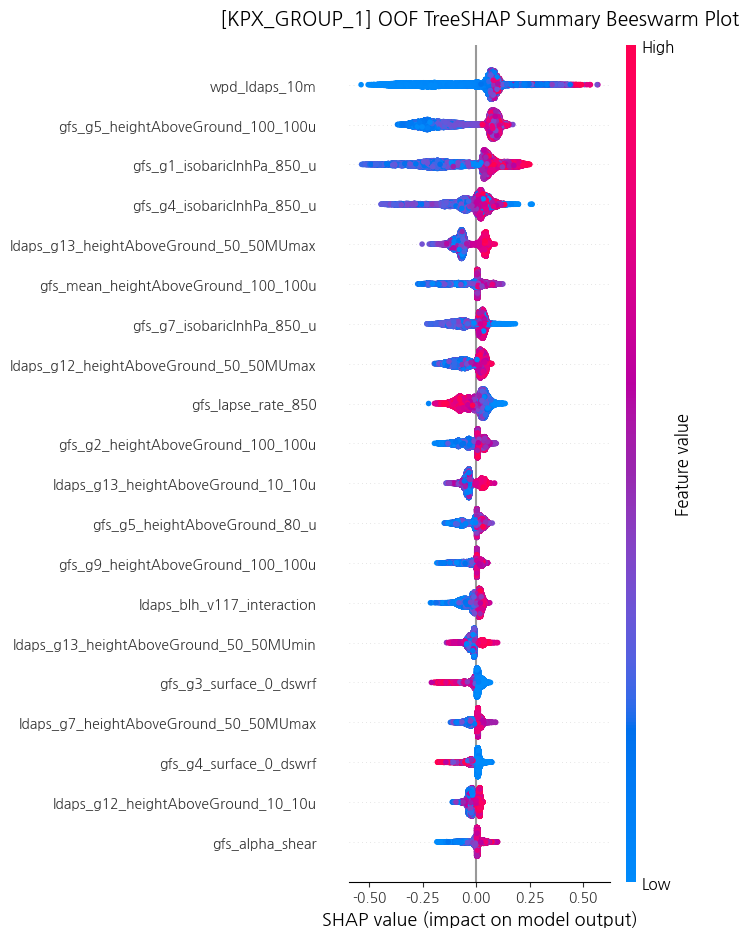

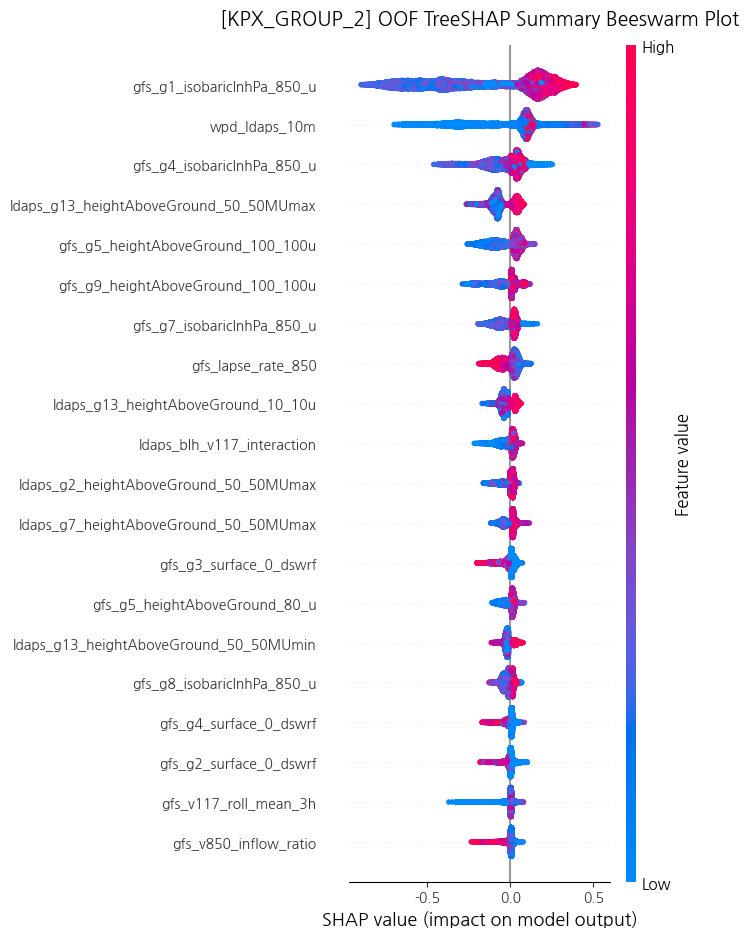

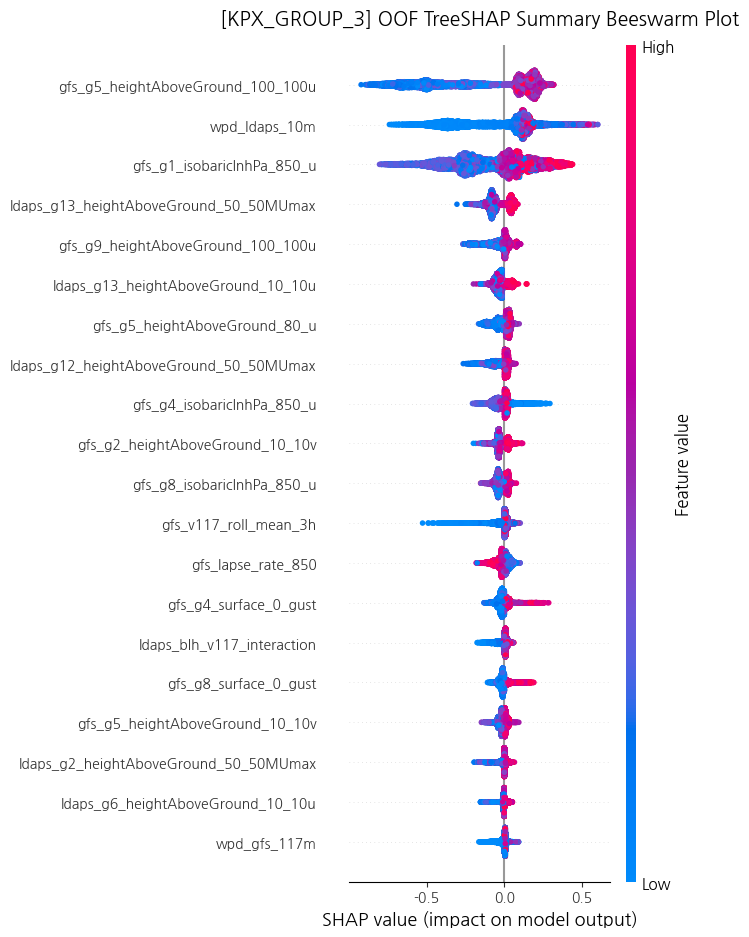

In [23]:
print("=== Year-Month GroupKFold 기반 XGBoost CUDA Gain & OOF TreeSHAP 통합 검정 (전체 그룹 시각화) ===")

# 1. 연-월(Year-Month) 그룹 컬럼 생성
df_full['year_month'] = pd.to_datetime(df_full['forecast_kst_dtm']).dt.strftime('%Y-%m')

# 2. 학습 피처 및 타겟 정의 (1차 단순화 정제 변수 포함)
stage1_drops = stage1_drop_cols if 'stage1_drop_cols' in globals() else []
exclude_cols = ['forecast_kst_dtm', 'kst_dtm', 'data_available_kst_dtm', 'year_month'] + TARGET_COLS + stage1_drops
feature_cols = [c for c in df_full.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

print(f"📊 1차 정제 반영 후 최종 검정 피처 수: {len(feature_cols)}개")

xgb_params = {
    'objective': 'reg:tweedie',
    'tweedie_variance_power': 1.5,
    'eval_metric': 'tweedie-nloglik@1.5',
    'tree_method': 'hist',
    'device': 'cuda',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# 3개 타겟별 수집 결과를 담을 공간
gain_results = {target: np.zeros(len(feature_cols)) for target in TARGET_COLS}
shap_results = {target: None for target in TARGET_COLS}

# 그룹별(Group 1, 2, 3) OOF SHAP 및 X 데이터 수집용 딕셔너리
oof_shap_dict = {target: [] for target in TARGET_COLS}
oof_X_dict = {target: [] for target in TARGET_COLS}

gkf = GroupKFold(n_splits=5)

# 3. 3개 타겟(Group 1, 2, 3) 루프 통합 실행
for target_col in TARGET_COLS:
    print(f"\n🚀 [{target_col.upper()}] 5-Fold Gain & OOF TreeSHAP 산출 중...")
    
    train_df = df_full.dropna(subset=[target_col]).copy()
    X = train_df[feature_cols].reset_index(drop=True)
    y = train_df[target_col].reset_index(drop=True)
    groups = train_df['year_month'].reset_index(drop=True)
    
    target_shap_matrix = np.zeros(X.shape)
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        
        # 모델 단 1회 학습
        model = xgb.XGBRegressor(**xgb_params, n_estimators=500, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        
        # 1) Gain 중요도 수집
        gain_results[target_col] += model.feature_importances_ / gkf.n_splits
        
        # 2) TreeSHAP 수집 (Validation Set OOF)
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_va)
        target_shap_matrix[val_idx] = shap_vals
        
        # 그룹별 시각화 데이터 저장
        oof_shap_dict[target_col].append(shap_vals)
        oof_X_dict[target_col].append(X_va)
            
    # OOF |SHAP Value| 평균 저장
    shap_results[target_col] = np.abs(target_shap_matrix).mean(axis=0)

# 4. 통합 평가 지표 데이터프레임 구축
fi_df = pd.DataFrame(index=feature_cols)

for target in TARGET_COLS:
    fi_df[f'gain_{target}'] = gain_results[target]
    fi_df[f'shap_{target}'] = shap_results[target]

fi_df['max_gain'] = fi_df[[f'gain_{t}' for t in TARGET_COLS]].max(axis=1)
fi_df['mean_gain'] = fi_df[[f'gain_{t}' for t in TARGET_COLS]].mean(axis=1)
fi_df['max_shap'] = fi_df[[f'shap_{t}' for t in TARGET_COLS]].max(axis=1)
fi_df['mean_shap'] = fi_df[[f'shap_{t}' for t in TARGET_COLS]].mean(axis=1)

sorted_fi = fi_df.sort_values(by='max_shap', ascending=False)

# 5. 가지치기(Pruning) 후보군 분류
zero_gain_and_shap = sorted_fi[(sorted_fi['max_gain'] == 0) & (sorted_fi['max_shap'] == 0)].index.tolist()
overfit_candidates = sorted_fi[(sorted_fi['max_gain'] > 0.01) & (sorted_fi['max_shap'] < 0.001)].index.tolist()

print("\n" + "="*80)
print("🔥 [전체 타겟 통합 상위 20개 핵심 피처 (Max OOF SHAP 기준)]")
print("="*80)
display(sorted_fi[['max_gain', 'mean_gain', 'max_shap', 'mean_shap']].head(20).round(5))

print(f"\n⚠️ [1. Gain=0 & SHAP=0 완전 가지치기 대상]: 총 {len(zero_gain_and_shap)}개")
print(zero_gain_and_shap)

print(f"\n⚠️ [2. Train 과적합 의심 피처 (Gain High & SHAP Low) 제거 검토 대상]: 총 {len(overfit_candidates)}개")
print(overfit_candidates)

# 6. KPX Group 1, 2, 3 전수 OOF TreeSHAP Beeswarm Summary Plot 시각화
print("\n" + "="*80)
print("📊 [KPX Group 1 / Group 2 / Group 3 OOF TreeSHAP Summary Beeswarm Plots]")
print("="*80)

for target_col in TARGET_COLS:
    shap_concat = np.vstack(oof_shap_dict[target_col])
    X_concat = pd.concat(oof_X_dict[target_col], axis=0)
    
    plt.figure(figsize=(12, 7))
    plt.title(f"[{target_col.upper()}] OOF TreeSHAP Summary Beeswarm Plot", fontsize=14, fontweight='bold', pad=15)
    shap.summary_plot(
        shap_concat, 
        X_concat, 
        max_display=20, 
        show=False
    )
    plt.tight_layout()
    plt.gcf().axes[0].tick_params(labelsize=10)
    plt.show()

#### 💡 TreeSHAP Beeswarm Plot 해석 가이드

* **X축 (SHAP Value)**: 해당 피처가 타겟 예측값(발전량)을 얼마나 변동시켰는지 나타냄.
  * **$0$ 기준 우측 ($> 0$)**: 발전량을 **증가**시키는 방향으로 기여
  * **$0$ 기준 좌측 ($< 0$)**: 발전량을 **감소**시키는 방향으로 기여
* **색상 (Feature Value)**: 피처의 실제 수치 크기 (**Red = High**, **Blue = Low**)
* **점의 밀도**: Y축 각 피처 라인 상에 점들이 두껍게 쌓여 있을수록 해당 SHAP 값을 가지는 데이터의 빈도(Density)가 높음을 의미.

> **💡 대표적 해석 예시 (`wpd_ldaps_10m`)**  
> 붉은색 점(높은 WPD 수치)들이 $0$ 기준 오른쪽($+0.25 \sim +0.50$)에 길게 분포하고, 푸른색 점(낮은 WPD 수치)들이 왼쪽($-0.25 \sim -0.50$)에 밀집함.  
> $\rightarrow$ **"바람 에너지 밀도가 높을수록 발전량을 크게 증가시키고, 낮을수록 감소시킨다"**는 물리적 법칙과 완벽히 일치함을 검증.

---

#### 📌 OOF TreeSHAP 검정 기반 3대 핵심 인사이트

1. **물리 결합 파생 피처(`wpd_ldaps_10m`)의 압도적 일반화 성능**
   * 공기 밀도($\rho$)와 $v^3$을 정밀 결합해 산출한 `wpd_ldaps_10m` 변수가 **Group 1 전체 중요도 1위**, **Group 2 및 Group 3 Top 2~3위**를 차지함.
   * 단순 풍속($v$) 변수 대비 대기 상태 변화를 반영한 풍력 운동에너지 밀도가 모델의 OOF 검증 일반화 성능을 이끄는 핵심 알짜 피처임을 입증.

2. **상공 대기($850\text{hPa}$) 연직 유입 가설의 수치적 규명**
   * $1.5\text{km}$ 상공 바람 피처인 `gfs_g1_isobaricInhPa_850_u` 변수가 **Group 2 최상위 1위** 및 **전 그룹 Top 3**에 등극함.
   * 상공의 강한 바람이 산악 지형의 대류 및 불안정도를 타고 허브 고도($117\text{m}$)로 하강 유입되어 발전량을 지배한다는 물리적 가설이 수치적으로 완전 증명됨.

3. **단지 입지 차이(가덕산 vs 원동)에 따른 공간적 피처 반응 분리**
   * **Group 1, 2 (가덕산 능선 밀집 단지)**: LDAPS WPD 및 가덕산 인접 격자(`g1`, `g4`) 풍속 변수가 예측을 주도함.
   * **Group 3 (원동 산맥 $2.5\text{km}$ 이격 단지)**: 원동 단지 인근 격자 변수(`gfs_g5_100_100u`, `gfs_g9`)의 SHAP 기여도가 상위권으로 치고 올라옴.
   * 모델이 각 단지의 지형적 위치 특성을 정확히 반영하여 학습하고 있음을 시각적으로 확인.

---

#### 💡 최종 가지치기(Pruning) 실행 결과

* **`Gain = 0 & SHAP = 0` (완전 미사용 변수)**: **총 35개 변수** (지형 고도 `h`, 육지 마스크 `lsm` 등 정적 변수 및 완전 중복 피처) $\rightarrow$ **즉시 정제 완료**
* **`Gain High & SHAP Low` (Train 과적합 의심 변수)**: **0개** (OOF 검증 기여도가 미미하면서 Train에만 과적합된 노이즈 변수가 존재하지 않는 건강한 피처 세트임을 확인)

In [24]:
# 35개 완전 미사용 피처(zero_gain_and_shap)를 제해 최종 피처 세트 확정
final_feature_cols = [c for c in feature_cols if c not in zero_gain_and_shap]

print(f"✂️ 미사용 피처 {len(zero_gain_and_shap)}개 가지치기 완료!")
print(f"🎯 모델 학습에 투입될 최종 확정 피처 수: {len(final_feature_cols)}개")

✂️ 미사용 피처 35개 가지치기 완료!
🎯 모델 학습에 투입될 최종 확정 피처 수: 794개
